# Comprehensive Exploratory Data Analysis (EDA) for VLST Dataset

## Overview

This notebook performs a thorough exploratory data analysis of the VLST (Very Late Stent Thrombosis) dataset. The analysis focuses on understanding the relationship between various clinical, procedural, and laboratory variables with the target outcome: **Stent thrombosis**.

### Objectives

1. **Data Quality Assessment**: Understand data completeness, missing values, and data types
2. **Target Variable Analysis**: Examine the distribution and characteristics of stent thrombosis cases
3. **Univariate Analysis**: Explore individual features and their distributions
4. **Bivariate Analysis**: Identify relationships between features and the target variable
5. **Statistical Testing**: Determine statistically significant associations
6. **Visualization**: Create high-quality visualizations to communicate findings
7. **Key Insights**: Extract actionable insights for further analysis and modeling

### Dataset Information

- **Target Variable**: `Stent thrombosis` (Binary: 0 = No, 1 = Yes)
- **Total Features**: 85 columns including clinical, procedural, and laboratory variables
- **Sample Size**: ~5,186 patients

---



## 1. Setup and Imports

First, we'll import all necessary libraries for data manipulation, statistical analysis, and visualization.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
import warnings
import os

warnings.filterwarnings('ignore')

# Set style for better-looking plots
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Set random seed for reproducibility
np.random.seed(42)

# Create output directory for plots
os.makedirs('../data/result/eda/plots', exist_ok=True)

print("✓ Libraries imported successfully!")
print("✓ Plot style configured!")
print("✓ Output directory created!")


✓ Libraries imported successfully!
✓ Plot style configured!
✓ Output directory created!


## 2. Data Loading

We'll load the VLST dataset from the raw data directory. Let's examine the basic structure and dimensions of the dataset.


In [29]:
# Load the dataset
df = pd.read_csv('../data/raw/VLST.csv')
df.drop(columns=["NO.", "Name"], inplace=True)

print("=" * 80)
print("DATA LOADING SUMMARY")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n✓ Data loaded successfully!")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()


DATA LOADING SUMMARY
Dataset shape: 5,185 rows × 83 columns
Memory usage: 3.52 MB

✓ Data loaded successfully!

First 5 rows of the dataset:


,Stent thrombosis,Age,Men,Time since stent implantation,Diabetes,Hypertension,HL,Current smoker,Current drinking,Stroke/TIA,...,LDL,HDL,TG,Fast-Glu,HbA1c,Fiberinogen,Aspirin,Clopidogrel,Ticagrelor,DAPT
0,0,36,1,1243,1,1,0,1,1,0,...,2.60,0.87,4.20,7.64,6.8,2.14,1,0,0,0
1,0,47,1,1540,0,0,0,1,0,0,...,1.41,1.88,1.37,4.99,4.6,1.71,1,1,0,1
2,0,45,1,1567,1,0,1,1,0,0,...,2.71,1.03,2.38,8.10,9.3,3.01,1,1,0,1
3,0,47,1,1502,0,1,0,0,1,0,...,2.03,1.06,1.77,7.17,6.9,2.11,1,0,0,0
4,0,57,1,1530,0,0,0,1,0,0,...,2.80,1.11,2.15,20.98,9.6,2.17,0,0,0,0


## 3. Data Overview

Let's examine the data types, column names, and get a comprehensive understanding of the dataset structure.


In [30]:
# Display basic information about the dataset
print("=" * 80)
print("DATA OVERVIEW")
print("=" * 80)

print(f"\nDataset Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n\nData Types Summary:")
print(df.dtypes.value_counts())

# Identify target variable
TARGET_COL = 'Stent thrombosis'
print(f"\n✓ Target variable identified: '{TARGET_COL}'")


DATA OVERVIEW

Dataset Dimensions: 5,185 rows × 83 columns

Column Names (83 total):
   1. Stent thrombosis
   2. Age
   3. Men
   4. Time since stent implantation
   5. Diabetes
   6. Hypertension
   7. HL
   8. Current smoker
   9. Current drinking
  10. Stroke/TIA
  11. History of peripheral vascualr disease
  12. Chronic renal insufficiency
  13. History of HF
  14. Previous CABG
  15. Previous PCI
  16. Previous MI
  17. Initial diagnosis-AMI
  18. STEMI
  19. NSTEMI
  20. UA
  21. Cardiogenic shock
  22. NO.of vessels
  23. Multi-vessel CAD
  24. Single-vessel disease
  25. 2-vessel disease
  26. 3-vessel disease
  27. Chronic total occlusion
  28. Moderate/severe calcification
  29. Moderate/severe tortuosity
  30. Lesion location-Ostial
  31. Proximal
  32. Bifurcation
  33. Visual thrombus
  34. Aneurysm
  35. Vessel dialation
  36. Ulceration
  37. P-LM
  38. P-LAD
  39. P-LCX
  40. P-RCA
  41. Pre-TIMI flow-3
  42. TIMI-2
  43. TIMI-1
  44. TIMI-0
  45. Staged PCI
  46. Thro

## 4. Missing Value Analysis

Missing data can significantly impact analysis and modeling. We need to:
- Identify which columns have missing values
- Quantify the extent of missingness
- Understand patterns in missing data

This will help us decide on appropriate imputation strategies or feature selection approaches.


In [31]:
# Calculate missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)

print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

if len(missing_df) > 0:
    print(f"\nTotal columns with missing values: {len(missing_df)}")
    print(f"Total missing values: {missing_data.sum():,}")
    total_cells = df.shape[0] * df.shape[1]
    print(f"Percentage of missing data: {(missing_data.sum() / total_cells) * 100:.2f}%")
    print(f"\nTop 20 columns with missing values:")
    print(missing_df.head(20).to_string(index=False))
else:
    print("✓ No missing values found in the dataset!")


MISSING VALUE ANALYSIS
✓ No missing values found in the dataset!


In [33]:
# Visualize missing values
if len(missing_df) > 0:
    top_missing = missing_df.head(20)
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=top_missing, y='Column', x='Missing Percentage', palette='viridis')
    ax.set_title('Top 20 Columns with Missing Values', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Percentage (%)', fontsize=12)
    ax.set_ylabel('Column Name', fontsize=12)
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/02_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Visualization saved: plots/02_missing_values.png")


## 5. Target Variable Analysis

The target variable **"Stent thrombosis"** is the primary outcome we're trying to predict. Understanding its distribution is crucial for:

- **Class Imbalance Detection**: Severe imbalance may require special techniques (SMOTE, class weights, etc.)
- **Baseline Performance**: Understanding the prevalence helps set expectations for model performance
- **Stratification**: Ensuring proper train/test splits maintain class distribution

Let's examine the distribution of stent thrombosis cases.


In [34]:
# Analyze target variable distribution
target_counts = df[TARGET_COL].value_counts()
target_percent = df[TARGET_COL].value_counts(normalize=True) * 100

print("=" * 80)
print("TARGET VARIABLE ANALYSIS: Stent thrombosis")
print("=" * 80)

print(f"\nTarget variable distribution:")
print(f"  Class 0 (No thrombosis): {target_counts.get(0, 0):,} ({target_percent.get(0, 0):.2f}%)")
print(f"  Class 1 (Thrombosis):   {target_counts.get(1, 0):,} ({target_percent.get(1, 0):.2f}%)")
print(f"  Total:                  {len(df):,}")

# Check for class imbalance
imbalance_ratio = min(target_counts) / max(target_counts) if len(target_counts) > 1 else 1
print(f"\nClass imbalance ratio: {imbalance_ratio:.3f}")
if imbalance_ratio < 0.3:
    print("⚠ Warning: Significant class imbalance detected!")
    print("   Consider using techniques like SMOTE, class weights, or stratified sampling.")
else:
    print("✓ Class distribution is relatively balanced.")


TARGET VARIABLE ANALYSIS: Stent thrombosis

Target variable distribution:
  Class 0 (No thrombosis): 5,093 (98.23%)
  Class 1 (Thrombosis):   92 (1.77%)
  Total:                  5,185

Class imbalance ratio: 0.018
⚠ Warning: Significant class imbalance detected!
   Consider using techniques like SMOTE, class weights, or stratified sampling.


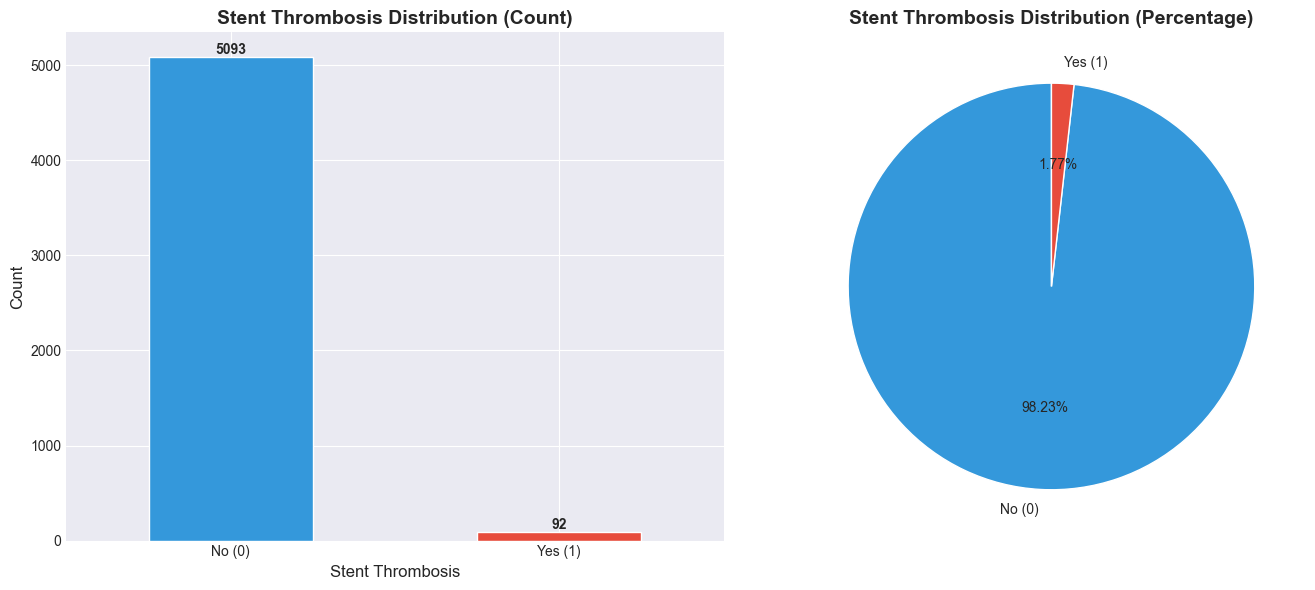

✓ Visualization saved: plots/01_target_distribution.png


In [35]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Stent Thrombosis Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stent Thrombosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
target_percent.plot(kind='pie', ax=axes[1], autopct='%1.2f%%', startangle=90,
                     colors=['#3498db', '#e74c3c'], labels=['No (0)', 'Yes (1)'])
axes[1].set_title('Stent Thrombosis Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/result/eda/plots/01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualization saved: plots/01_target_distribution.png")


## 6. Feature Categorization

Before diving into detailed analysis, we need to categorize features into different types:

- **Binary Features**: Variables that take only 0/1 values (e.g., presence/absence indicators)
- **Continuous Features**: Numeric variables that can take any value in a range (e.g., age, lab values)
- **Categorical Features**: Text or nominal variables (e.g., stent type names)

This categorization helps us choose appropriate statistical tests and visualization methods for each feature type.


In [36]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from numeric for analysis
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

# Binary columns (0/1)
binary_cols = []
for col in numeric_cols:
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, np.nan}):
        binary_cols.append(col)

# Continuous numeric columns
continuous_cols = [col for col in numeric_cols if col not in binary_cols]

print("=" * 80)
print("FEATURE CATEGORIZATION")
print("=" * 80)

print(f"\nFeature categories:")
print(f"  Total features: {len(df.columns) - 1} (excluding target)")
print(f"  Binary features: {len(binary_cols)}")
print(f"  Continuous features: {len(continuous_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")

print(f"\n\nSample binary features (first 10):")
for i, col in enumerate(binary_cols[:10], 1):
    print(f"  {i:2d}. {col}")

print(f"\n\nSample continuous features (first 10):")
for i, col in enumerate(continuous_cols[:10], 1):
    print(f"  {i:2d}. {col}")

if categorical_cols:
    print(f"\n\nCategorical features:")
    for i, col in enumerate(categorical_cols, 1):
        print(f"  {i:2d}. {col}")


FEATURE CATEGORIZATION

Feature categories:
  Total features: 82 (excluding target)
  Binary features: 57
  Continuous features: 24
  Categorical features: 1


Sample binary features (first 10):
   1. Men
   2. Diabetes
   3. Hypertension
   4. HL
   5. Current smoker
   6. Current drinking
   7. Stroke/TIA
   8. History of peripheral vascualr disease
   9. Chronic renal insufficiency
  10. History of HF


Sample continuous features (first 10):
   1. Age
   2. Time since stent implantation
   3. NO.of vessels
   4. Min-stent diameter
   5. Max-stent diameter
   6. Total stent length
   7. Stent release pressure
   8. No.of stents per lesion
   9. LV
  10. LVEF


Categorical features:
   1. Stent type-SES


## 7. Univariate Analysis - Continuous Variables

Univariate analysis examines individual features in isolation. For continuous variables, we'll look at:

- **Central Tendency**: Mean, median, mode
- **Dispersion**: Standard deviation, range, quartiles
- **Distribution Shape**: Skewness, kurtosis
- **Outliers**: Values that deviate significantly from the norm

Understanding these characteristics helps identify:
- Features that need transformation (e.g., log transformation for skewed data)
- Potential data quality issues
- Features with unusual distributions


In [37]:
# Summary statistics for continuous variables
if len(continuous_cols) > 0:
    print("=" * 80)
    print("UNIVARIATE ANALYSIS - CONTINUOUS VARIABLES")
    print("=" * 80)
    
    continuous_stats = df[continuous_cols].describe()
    print("\nSummary statistics for continuous variables:")
    display(continuous_stats.T.round(2))
else:
    print("No continuous variables found.")


UNIVARIATE ANALYSIS - CONTINUOUS VARIABLES

Summary statistics for continuous variables:


,count,mean,std,min,25%,50%,75%,max
Age,5185.0,59.85,9.95,28.00,53.00,60.00,67.00,89.00
Time since stent implantation,5185.0,1409.96,140.30,380.00,1319.00,1416.00,1514.00,1605.00
NO.of vessels,5185.0,1.87,0.82,1.00,1.00,2.00,3.00,4.00
Min-stent diameter,5185.0,2.99,0.41,2.25,2.75,3.00,3.00,5.00
Max-stent diameter,5185.0,3.06,0.41,2.25,2.75,3.00,3.50,5.00
Total stent length,5185.0,31.82,15.75,8.00,21.00,28.00,36.00,144.00
Stent release pressure,5185.0,13.95,2.98,6.00,12.00,14.00,16.00,24.00
No.of stents per lesion,5185.0,1.22,0.46,1.00,1.00,1.00,1.00,4.00
LV,5185.0,44.63,4.09,37.00,42.00,44.00,46.00,73.00
LVEF,5185.0,55.14,4.50,22.00,53.00,55.00,58.00,68.00


In [38]:
# Outlier detection using IQR method
if len(continuous_cols) > 0:
    print("\n" + "-" * 80)
    print("OUTLIER DETECTION (IQR Method)")
    print("-" * 80)
    
    outlier_summary = []
    for col in continuous_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR > 0:  # Avoid division by zero
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_count = len(outliers)
            if outlier_count > 0:
                outlier_summary.append({
                    'Column': col,
                    'Outliers': outlier_count,
                    'Percentage': (outlier_count / len(df)) * 100,
                    'Lower Bound': lower_bound,
                    'Upper Bound': upper_bound
                })
    
    if outlier_summary:
        outlier_df = pd.DataFrame(outlier_summary).sort_values('Outliers', ascending=False)
        print(f"\nColumns with outliers (top 20):")
        display(outlier_df.head(20))
    else:
        print("✓ No outliers detected using IQR method")



--------------------------------------------------------------------------------
OUTLIER DETECTION (IQR Method)
--------------------------------------------------------------------------------

Columns with outliers (top 20):


,Column,Outliers,Percentage,Lower Bound,Upper Bound
2,Min-stent diameter,1348,25.998071,2.375,3.375
8,CaI,645,12.439730,-56.200,100.440
4,Total stent length,434,8.370299,-1.500,58.500
18,Fast-Glu,418,8.061716,1.620,10.820
6,LV,247,4.763742,36.000,52.000
7,LVEF,231,4.455159,45.500,65.500
12,Cre,194,3.741562,26.000,114.000
20,Fiberinogen,193,3.722276,1.240,4.920
19,HbA1c,159,3.066538,1.450,9.850
9,WBC,153,2.950820,0.135,16.415


## 8. Univariate Analysis - Binary Variables

For binary variables, we examine:
- **Prevalence**: What percentage of cases have the feature present (value = 1)?
- **Distribution**: Are the classes balanced or is one value much more common?

This helps identify:
- Rare features (very low or very high prevalence) that may have limited predictive power
- Features with balanced distributions that might be more informative


In [39]:
# Binary variable analysis
if len(binary_cols) > 0:
    print("=" * 80)
    print("UNIVARIATE ANALYSIS - BINARY VARIABLES")
    print("=" * 80)
    
    binary_summary = []
    for col in binary_cols:
        positive_count = df[col].sum()
        positive_pct = (positive_count / len(df)) * 100
        binary_summary.append({
            'Column': col,
            'Positive (1)': positive_count,
            'Negative (0)': len(df) - positive_count,
            'Percentage Positive': positive_pct
        })
    
    binary_df = pd.DataFrame(binary_summary).sort_values('Percentage Positive')
    print("\nBinary variable distribution (sorted by prevalence):")
    display(binary_df.head(20))
    
    print("\n...")
    print(f"\nTotal binary variables analyzed: {len(binary_df)}")


UNIVARIATE ANALYSIS - BINARY VARIABLES

Binary variable distribution (sorted by prevalence):


,Column,Positive (1),Negative (0),Percentage Positive
29,Aneurysm,28.0,5157.0,0.540019
31,Ulceration,39.0,5146.0,0.752170
43,No reflow,44.0,5141.0,0.848602
44,Dissection,53.0,5132.0,1.022179
30,Vessel dialation,59.0,5126.0,1.137898
24,Moderate/severe tortuosity,60.0,5125.0,1.157184
8,Chronic renal insufficiency,64.0,5121.0,1.234330
7,History of peripheral vascualr disease,88.0,5097.0,1.697203
55,Ticagrelor,91.0,5094.0,1.755063
11,Previous PCI,104.0,5081.0,2.005786



...

Total binary variables analyzed: 57


## 9. Bivariate Analysis - Correlations

Bivariate analysis examines relationships between features and the target variable. Correlation analysis helps us:

- **Identify Important Features**: Features with strong correlations are likely to be predictive
- **Understand Direction**: Positive correlation means feature increases with target, negative means it decreases
- **Detect Multicollinearity**: High correlations between features can indicate redundancy

We'll calculate Pearson correlation coefficients for numeric features with the target variable.


In [40]:
# Calculate correlations with target
if TARGET_COL in df.columns:
    correlations = df[numeric_cols + [TARGET_COL]].corr()[TARGET_COL].sort_values(ascending=False)
    correlations = correlations[correlations.index != TARGET_COL]
    
    print("=" * 80)
    print("BIVARIATE ANALYSIS - CORRELATIONS")
    print("=" * 80)
    
    print("\nTop 20 features most correlated with Stent thrombosis:")
    print(correlations.head(20).to_string())
    
    print("\n\nBottom 20 features least correlated with Stent thrombosis:")
    print(correlations.tail(20).to_string())
    
    # Strong correlations (absolute value > 0.3)
    strong_corr = correlations[abs(correlations) > 0.3]
    if len(strong_corr) > 0:
        print(f"\n✓ Found {len(strong_corr)} features with |correlation| > 0.3:")
        print(strong_corr.to_string())
    else:
        print("\n⚠ No features found with |correlation| > 0.3")


BIVARIATE ANALYSIS - CORRELATIONS

Top 20 features most correlated with Stent thrombosis:
WBC                        0.150203
LV                         0.147245
No postdilation            0.089266
Previous PCI               0.084973
CKD90                      0.062602
No.of stents per lesion    0.060360
Total stent length         0.056651
Fast-Glu                   0.053844
3-vessel disease           0.052003
NO.of vessels              0.051149
CKD5                       0.048615
Diabetes                   0.041555
PES                        0.039530
HbA1c                      0.038787
Multi-vessel CAD           0.038040
stent overlap              0.034669
TIMI-0                     0.033180
LDL                        0.029883
Stroke/TIA                 0.029607
Fiberinogen                0.029211


Bottom 20 features least correlated with Stent thrombosis:
Visual thrombus                 -0.002793
HL                              -0.003454
History of HF                   -0.003924
P-L

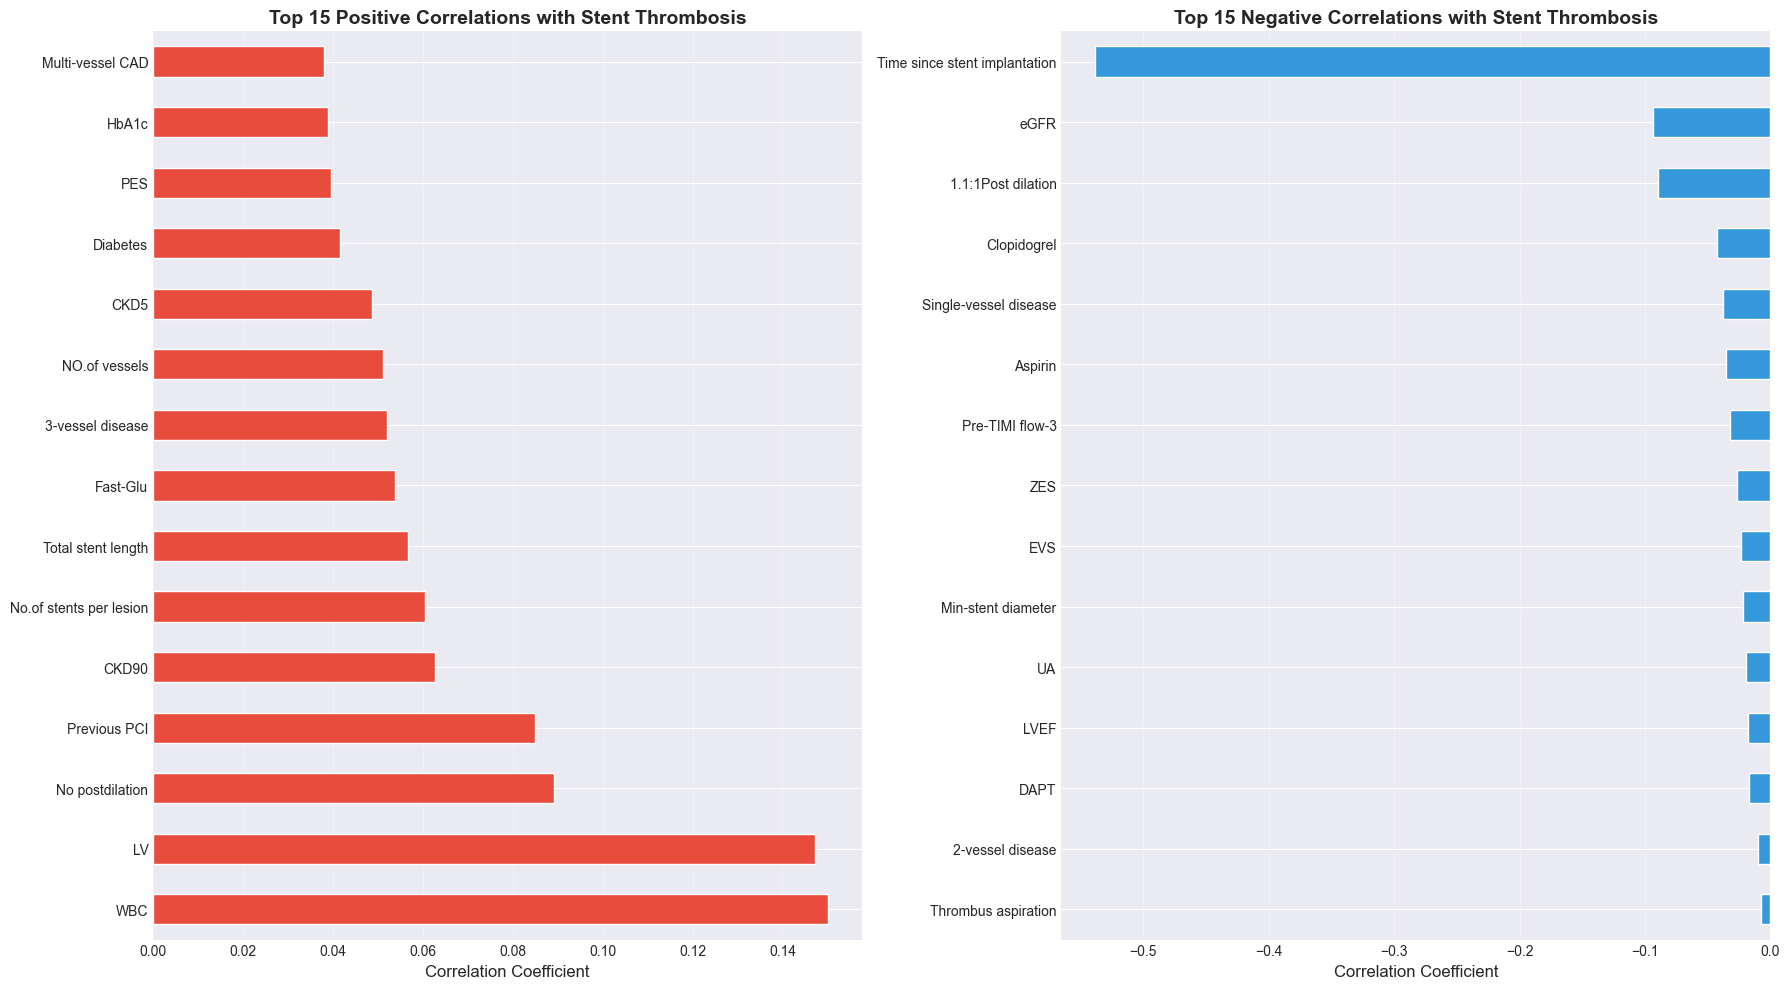

✓ Visualization saved: plots/07_top_correlations.png


In [41]:
# Visualize top correlations
if TARGET_COL in df.columns and len(correlations) > 0:
    top_pos = correlations.head(15)
    top_neg = correlations.tail(15)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    
    # Positive correlations
    top_pos.plot(kind='barh', ax=axes[0], color='#e74c3c')
    axes[0].set_title('Top 15 Positive Correlations with Stent Thrombosis', 
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Correlation Coefficient', fontsize=12)
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Negative correlations
    top_neg.plot(kind='barh', ax=axes[1], color='#3498db')
    axes[1].set_title('Top 15 Negative Correlations with Stent Thrombosis', 
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Correlation Coefficient', fontsize=12)
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/07_top_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Visualization saved: plots/07_top_correlations.png")


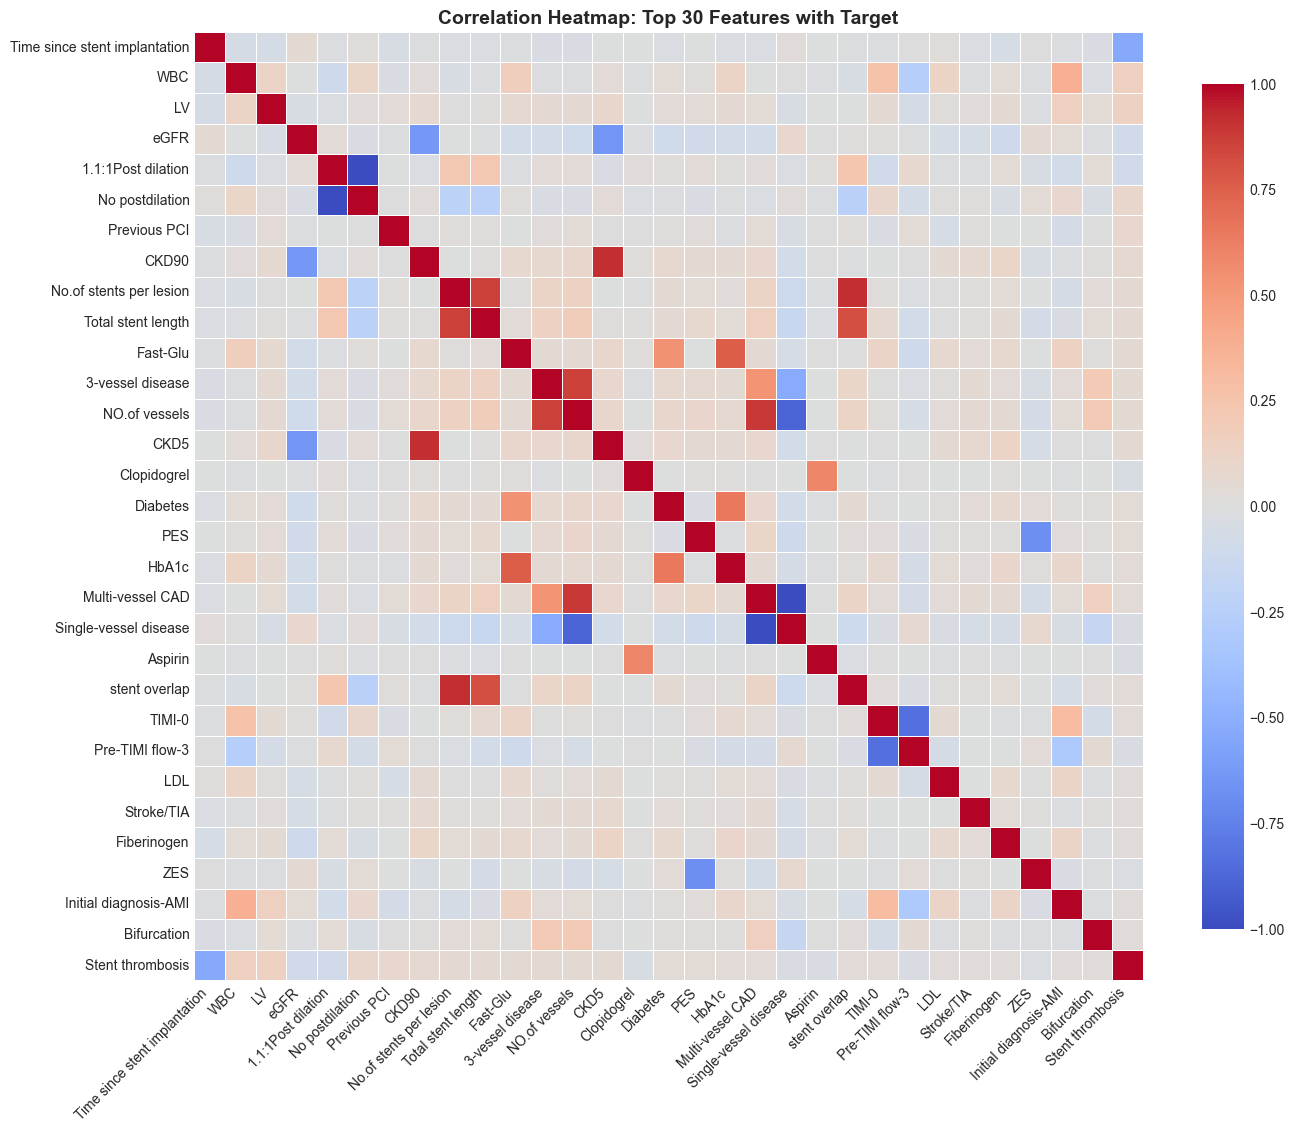

✓ Visualization saved: plots/03_correlation_heatmap.png


In [42]:
# Correlation heatmap
if len(continuous_cols) > 0:
    # Select top correlated features
    top_corr_features = correlations.abs().nlargest(30).index.tolist()
    corr_matrix = df[top_corr_features + [TARGET_COL]].corr()
    
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
    ax.set_title('Correlation Heatmap: Top 30 Features with Target', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Visualization saved: plots/03_correlation_heatmap.png")


## 10. Statistical Tests - Association with Target

While correlation provides a measure of linear relationship, statistical tests help us determine if observed differences are statistically significant or could have occurred by chance.

### Tests Used:

1. **Mann-Whitney U Test** (for continuous variables):
   - Non-parametric test comparing distributions between two groups
   - Tests the null hypothesis that both groups have the same distribution
   - Appropriate when data may not be normally distributed

2. **Chi-Square Test** (for binary variables):
   - Tests independence between two categorical variables
   - Determines if there's a significant association between a binary feature and the target

**Significance Level**: p < 0.05 indicates statistical significance


In [43]:
# Separate data by target
target_0 = df[df[TARGET_COL] == 0]
target_1 = df[df[TARGET_COL] == 1]

print("=" * 80)
print("STATISTICAL TESTS - ASSOCIATION WITH TARGET")
print("=" * 80)
print(f"\nGroup sizes: Class 0 = {len(target_0):,}, Class 1 = {len(target_1):,}")

# Statistical tests for continuous variables
print("\n" + "-" * 80)
print("Mann-Whitney U Test for Continuous Variables")
print("-" * 80)

test_results = []
for col in continuous_cols[:50]:  # Test top 50 to save time
    try:
        group_0 = target_0[col].dropna()
        group_1 = target_1[col].dropna()
        
        if len(group_0) > 0 and len(group_1) > 0 and len(group_0) > 3 and len(group_1) > 3:
            stat, p_value = mannwhitneyu(group_0, group_1, alternative='two-sided')
            test_results.append({
                'Feature': col,
                'Statistic': stat,
                'P-value': p_value,
                'Significant': 'Yes' if p_value < 0.05 else 'No'
            })
    except:
        pass

if test_results:
    test_df = pd.DataFrame(test_results).sort_values('P-value')
    print(f"\nTop 20 features by statistical significance:")
    display(test_df.head(20))
    
    significant = test_df[test_df['P-value'] < 0.05]
    print(f"\n✓ Found {len(significant)} continuous features with significant association (p < 0.05)")
else:
    print("No valid test results obtained.")


STATISTICAL TESTS - ASSOCIATION WITH TARGET

Group sizes: Class 0 = 5,093, Class 1 = 92

--------------------------------------------------------------------------------
Mann-Whitney U Test for Continuous Variables
--------------------------------------------------------------------------------

Top 20 features by statistical significance:


,Feature,Statistic,P-value,Significant
1,Time since stent implantation,408583.5,1.697913e-34,Yes
8,LV,92873.5,1.359932e-23,Yes
11,WBC,101400.5,7.902144e-21,Yes
15,eGFR,332986.5,4.016096e-12,Yes
16,CKD5,193418.0,1.186437e-05,Yes
7,No.of stents per lesion,196833.0,1.412198e-04,Yes
22,HbA1c,181409.0,1.975000e-04,Yes
2,NO.of vessels,185995.5,2.964337e-04,Yes
5,Total stent length,188100.5,1.122263e-03,Yes
23,Fiberinogen,198493.0,1.191098e-02,Yes



✓ Found 12 continuous features with significant association (p < 0.05)


In [44]:
# Chi-square tests for binary variables
print("\n" + "-" * 80)
print("Chi-Square Test for Binary Variables")
print("-" * 80)

chi2_results = []
for col in binary_cols[:50]:  # Test top 50
    try:
        contingency = pd.crosstab(df[col], df[TARGET_COL])
        if contingency.shape == (2, 2) and contingency.min().min() > 0:
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            chi2_results.append({
                'Feature': col,
                'Chi2': chi2,
                'P-value': p_value,
                'Significant': 'Yes' if p_value < 0.05 else 'No'
            })
    except:
        pass

if chi2_results:
    chi2_df = pd.DataFrame(chi2_results).sort_values('P-value')
    print(f"\nTop 20 features by statistical significance:")
    display(chi2_df.head(20))
    
    significant = chi2_df[chi2_df['P-value'] < 0.05]
    print(f"\n✓ Found {len(significant)} binary features with significant association (p < 0.05)")
else:
    print("No valid test results obtained.")



--------------------------------------------------------------------------------
Chi-Square Test for Binary Variables
--------------------------------------------------------------------------------

Top 20 features by statistical significance:


,Feature,Chi2,P-value,Significant
49,1.1:1Post dilation,39.973866,2.573836e-10,Yes
11,Previous PCI,32.987999,9.272948e-09,Yes
21,3-vessel disease,13.160275,2.859469e-04,Yes
1,Diabetes,8.246984,4.081976e-03,Yes
45,PES,7.467730,6.281470e-03,Yes
19,Single-vessel disease,6.928603,8.482791e-03,Yes
18,Multi-vessel CAD,6.928603,8.482791e-03,Yes
48,stent overlap,5.582974,1.813590e-02,Yes
39,TIMI-0,5.186198,2.276697e-02,Yes
36,Pre-TIMI flow-3,4.781493,2.876717e-02,Yes



✓ Found 10 binary features with significant association (p < 0.05)


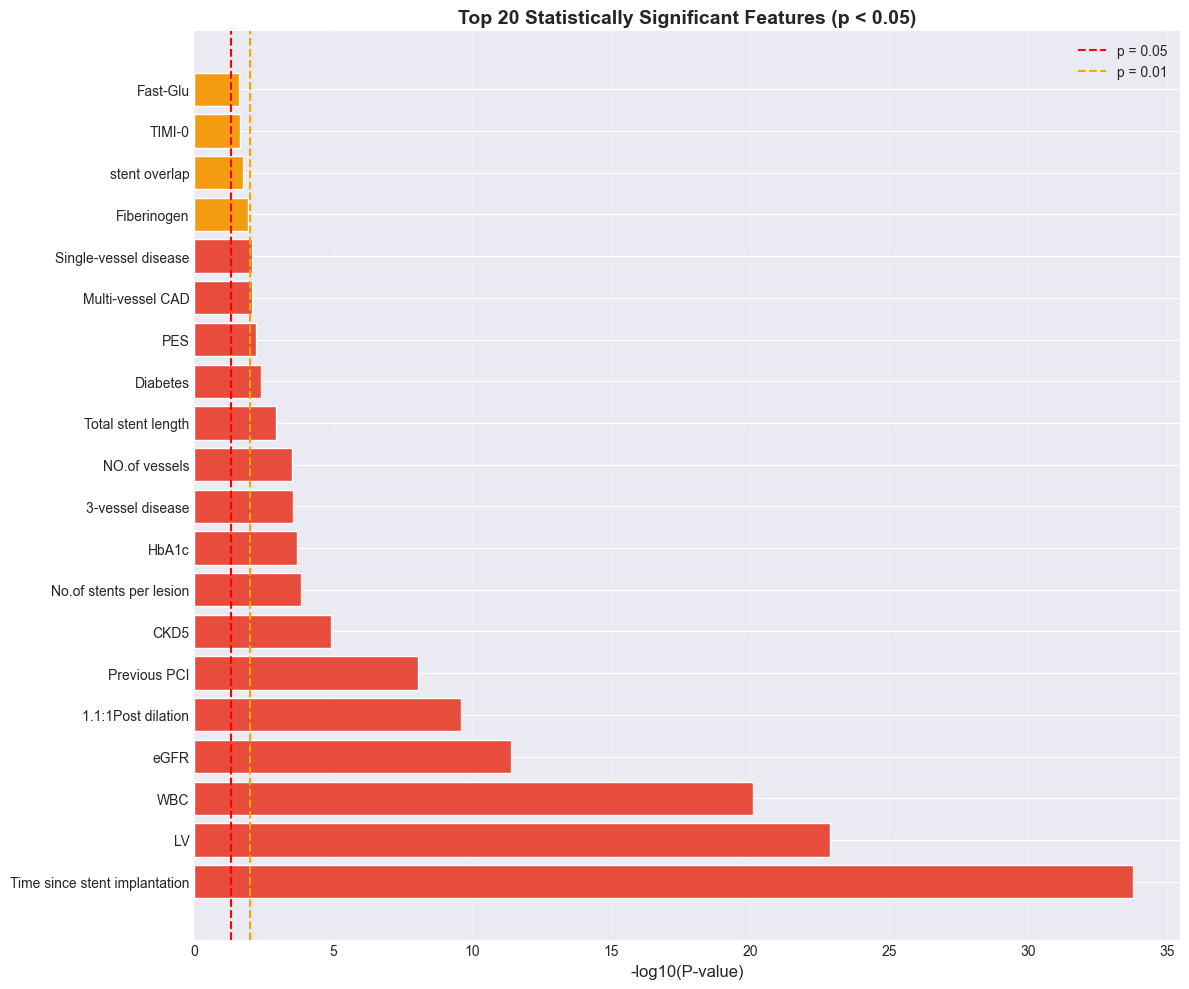

✓ Visualization saved: plots/08_statistical_significance.png


In [45]:
# Visualize statistical significance
if test_results and chi2_results:
    # Combine results
    all_results = []
    for r in test_results:
        all_results.append({'Feature': r['Feature'], 'P-value': r['P-value'], 'Test': 'Mann-Whitney U'})
    for r in chi2_results:
        all_results.append({'Feature': r['Feature'], 'P-value': r['P-value'], 'Test': 'Chi-Square'})
    
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values('P-value')
    top_significant = results_df[results_df['P-value'] < 0.05].head(20)
    
    if len(top_significant) > 0:
        fig, ax = plt.subplots(figsize=(12, 10))
        y_pos = np.arange(len(top_significant))
        colors = ['#e74c3c' if p < 0.01 else '#f39c12' if p < 0.05 else '#3498db' 
                  for p in top_significant['P-value']]
        
        ax.barh(y_pos, -np.log10(top_significant['P-value']), color=colors)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_significant['Feature'])
        ax.set_xlabel('-log10(P-value)', fontsize=12)
        ax.set_title('Top 20 Statistically Significant Features (p < 0.05)', 
                     fontsize=14, fontweight='bold')
        ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
        ax.axvline(x=-np.log10(0.01), color='orange', linestyle='--', label='p = 0.01')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.savefig('../data/result/eda/plots/08_statistical_significance.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Visualization saved: plots/08_statistical_significance.png")


## 11. Distribution Analysis - Continuous Variables by Target

Understanding how continuous variables differ between patients with and without stent thrombosis helps identify:
- **Risk Factors**: Variables where distributions differ significantly
- **Biomarkers**: Lab values or measurements that may indicate higher risk
- **Clinical Patterns**: Features that distinguish between the two groups

We'll visualize distributions using histograms and box plots.


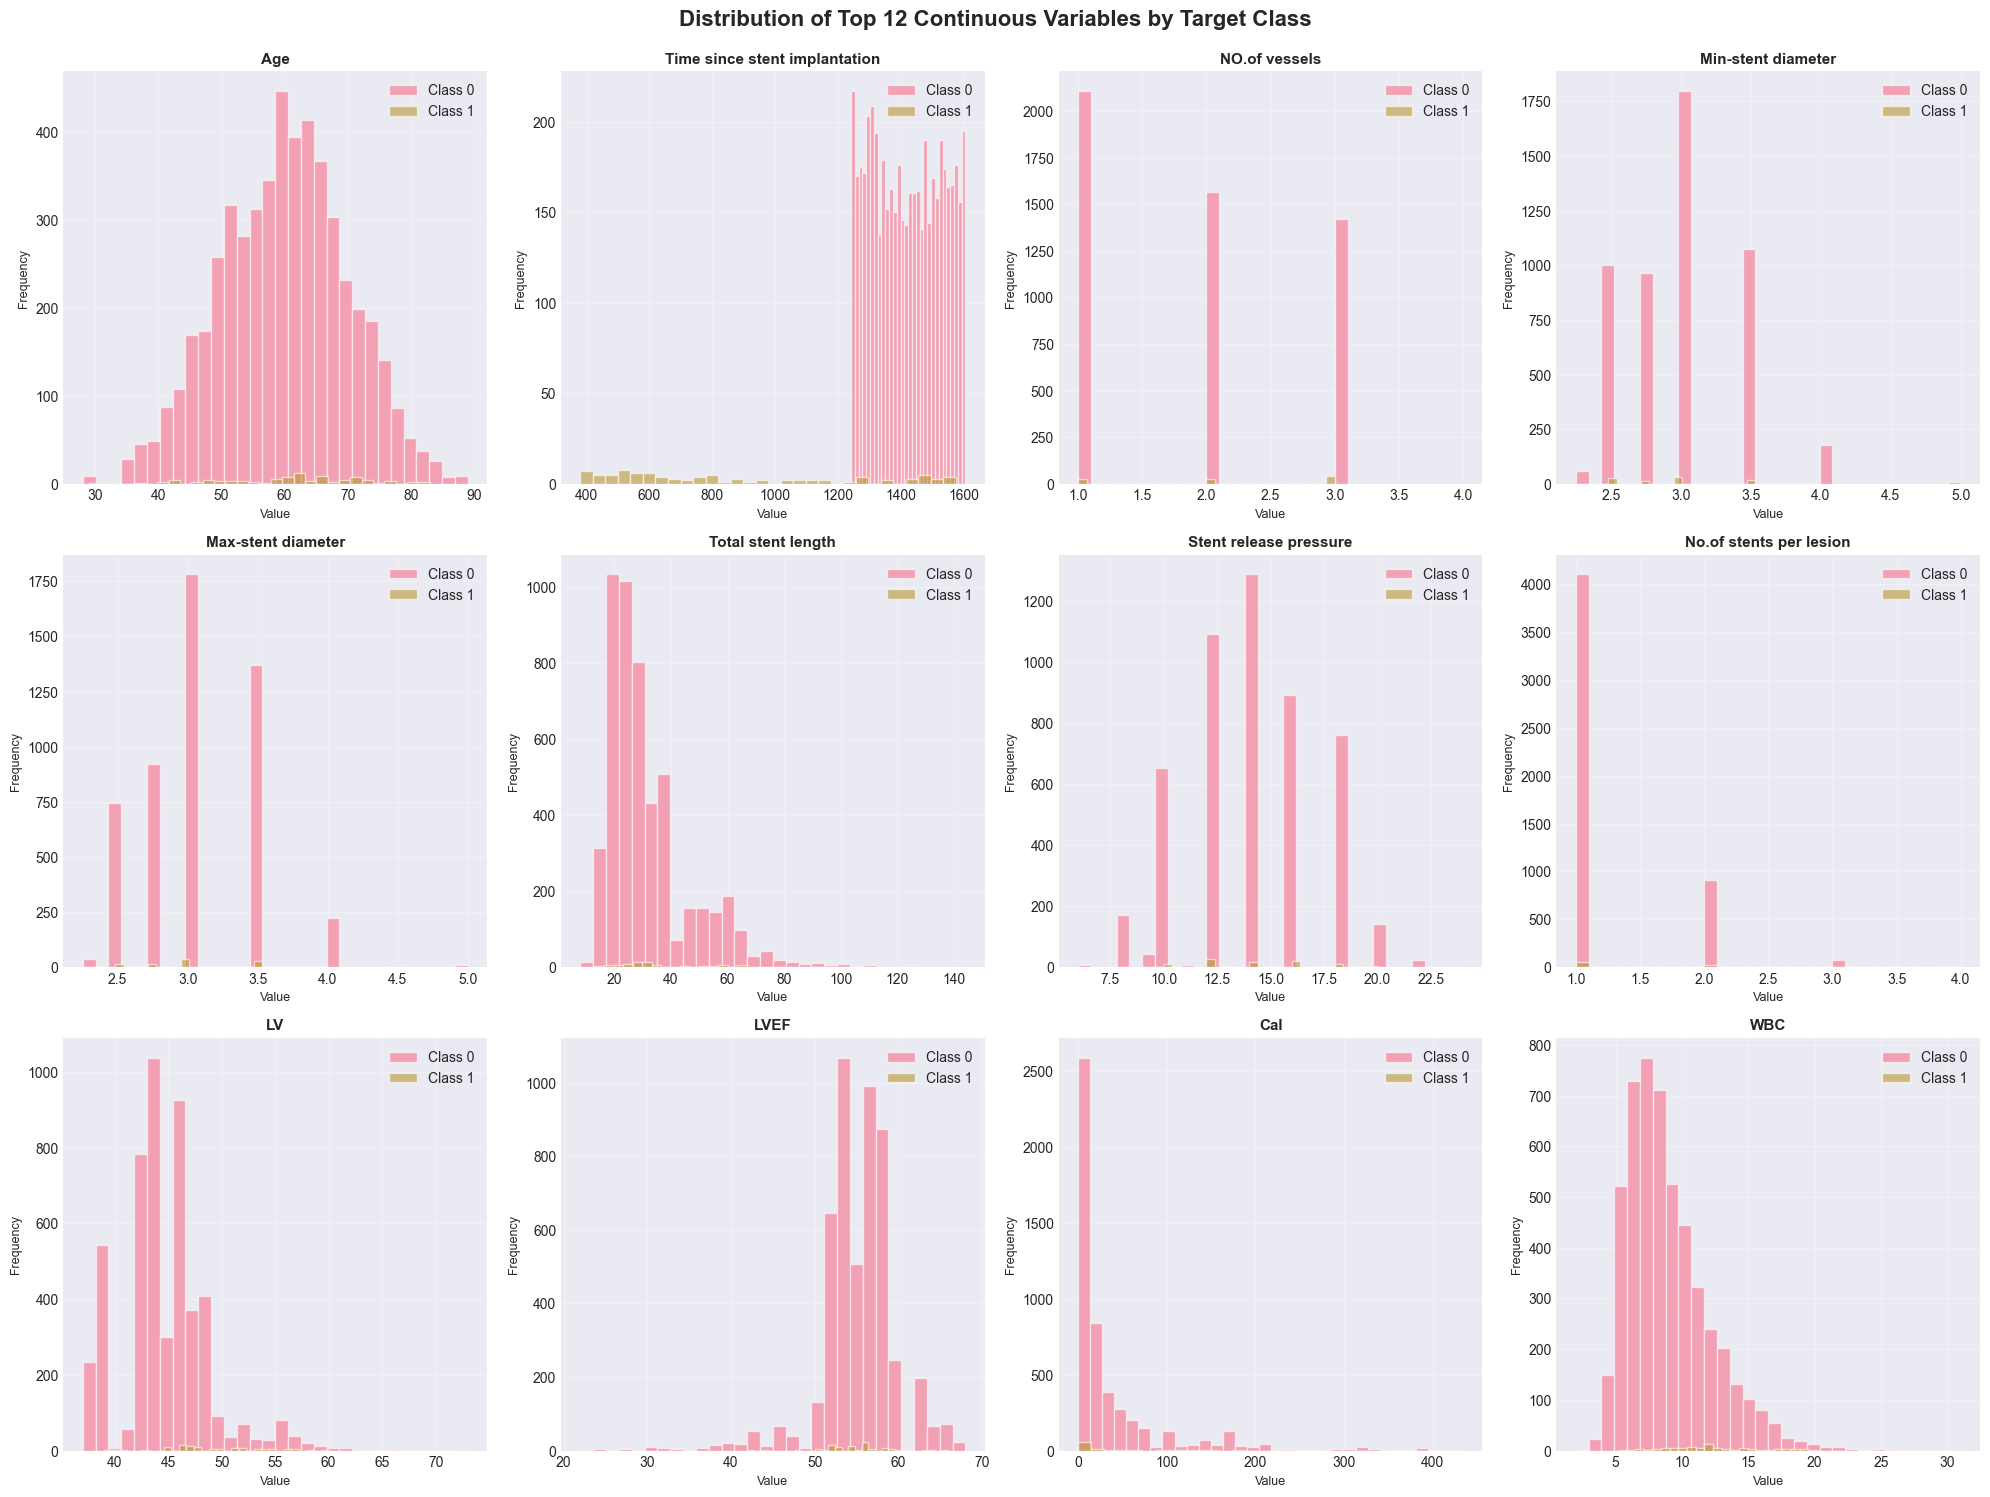

✓ Visualization saved: plots/04_continuous_distributions.png


In [47]:
# Distribution of continuous variables by target
if len(continuous_cols) > 0:
    top_continuous = continuous_cols[:12]  # Top 12 continuous variables
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    for idx, col in enumerate(top_continuous):
        try:
            df_clean = df[[col, TARGET_COL]].dropna()
            if len(df_clean) > 0:
                for target_val in [0, 1]:
                    data = df_clean[df_clean[TARGET_COL] == target_val][col]
                    axes[idx].hist(data, alpha=0.6, label=f'Class {target_val}', bins=30)
                axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
                axes[idx].set_xlabel('Value', fontsize=9)
                axes[idx].set_ylabel('Frequency', fontsize=9)
                axes[idx].legend()
                axes[idx].grid(True, alpha=0.3)
        except:
            axes[idx].axis('off')
    
    plt.suptitle('Distribution of Top 12 Continuous Variables by Target Class', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/04_continuous_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Visualization saved: plots/04_continuous_distributions.png")


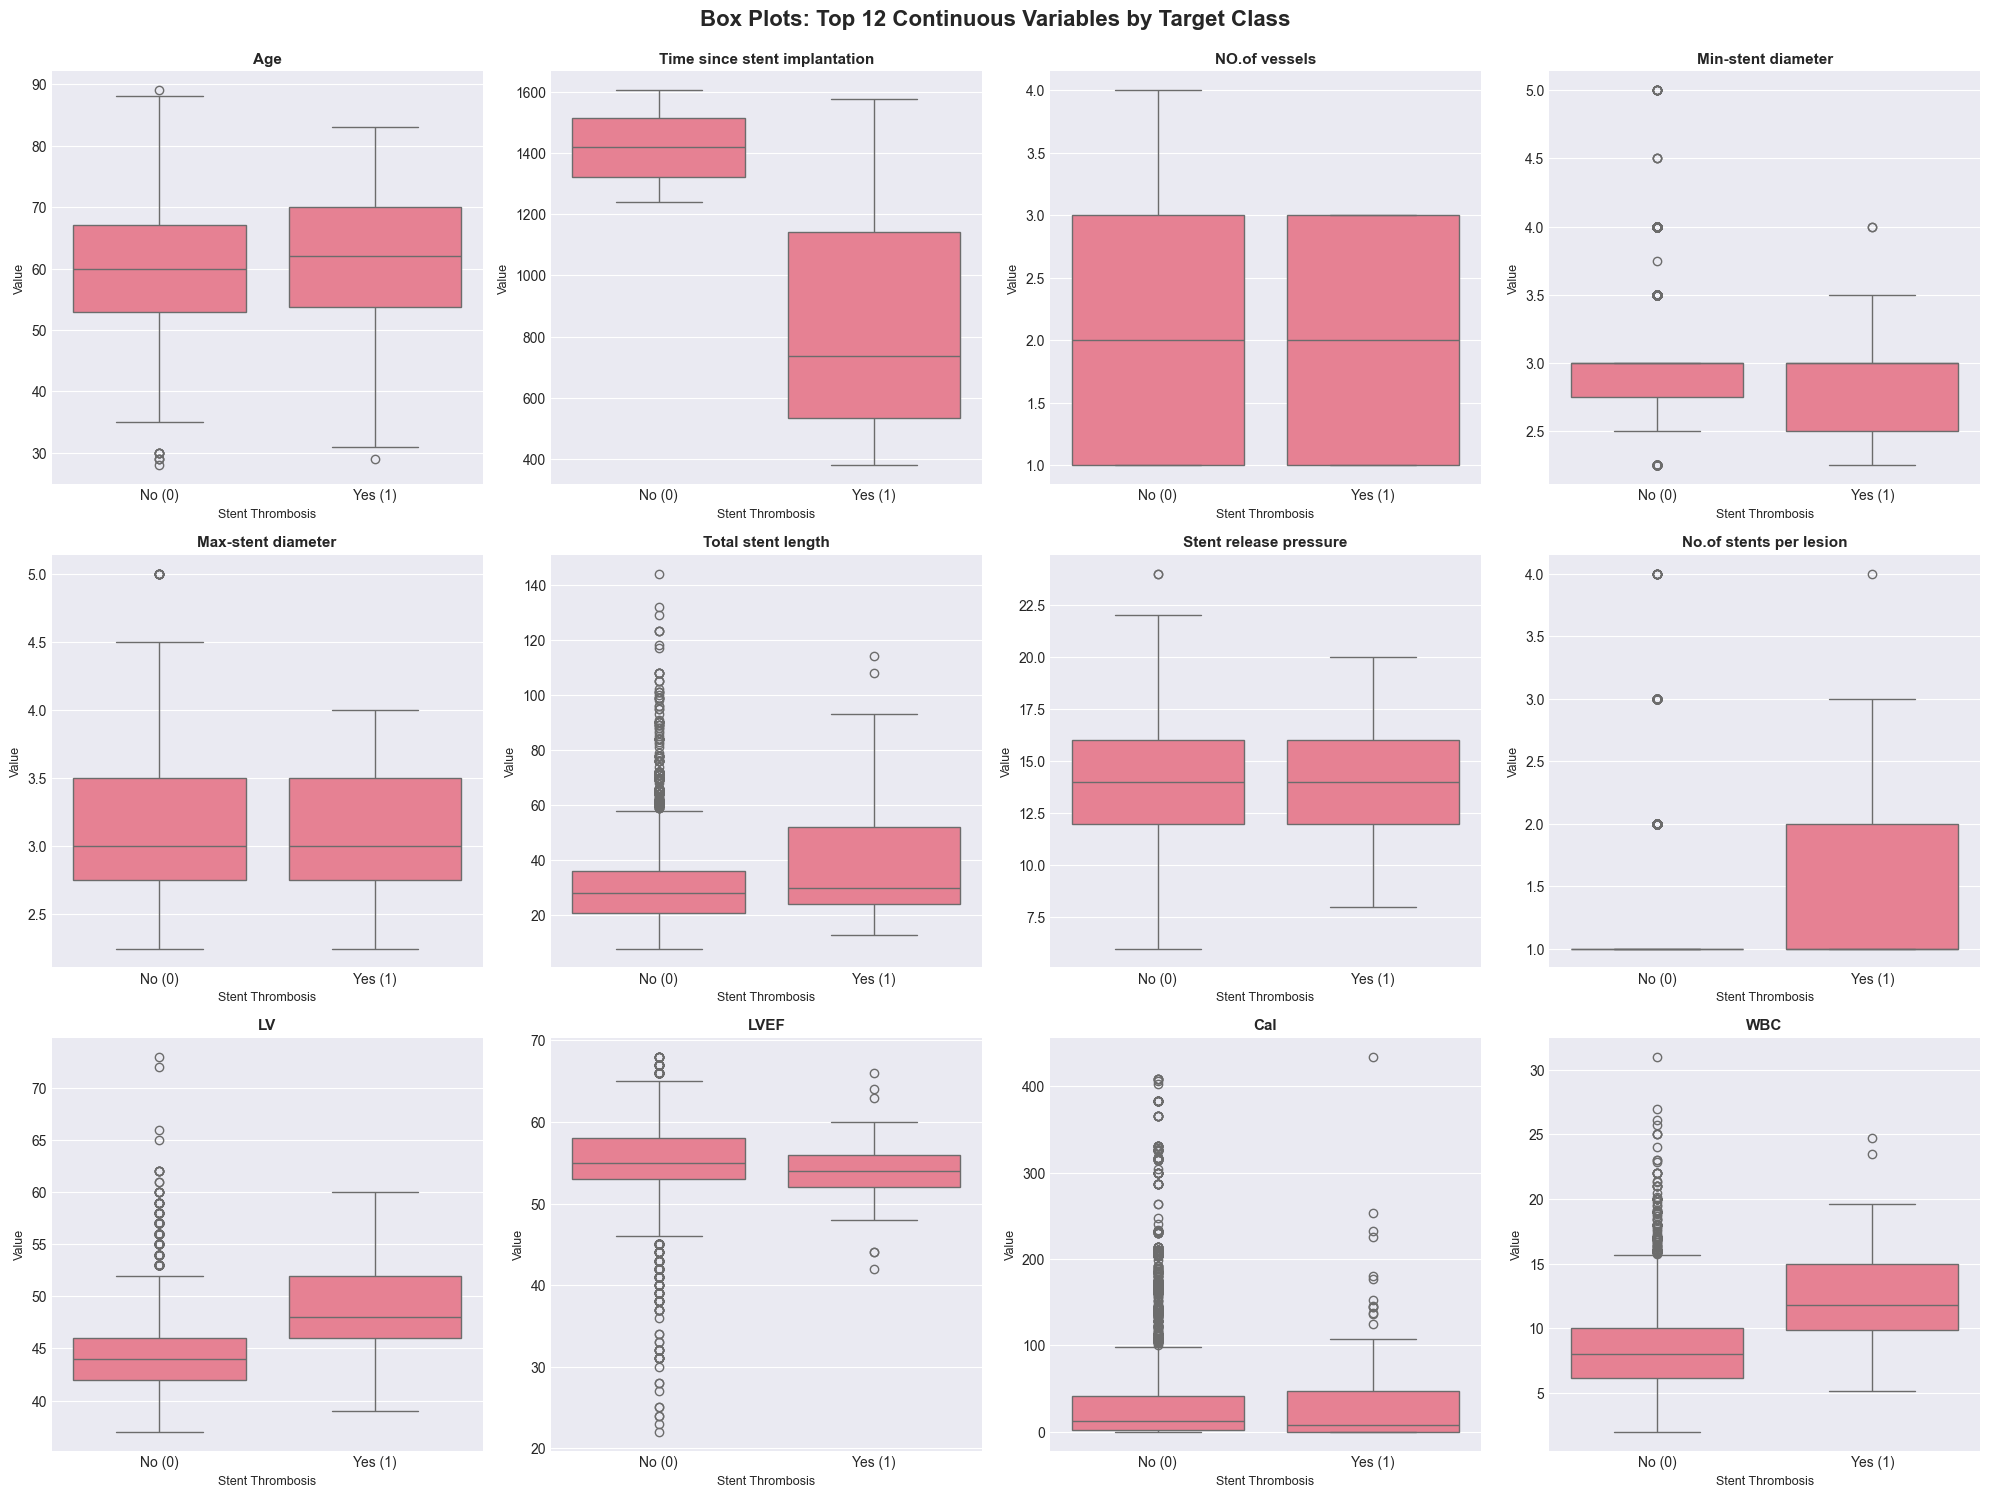

✓ Visualization saved: plots/05_boxplots_continuous.png


In [46]:
# Box plots for continuous variables
if len(continuous_cols) > 0:
    top_continuous = continuous_cols[:12]
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    for idx, col in enumerate(top_continuous):
        try:
            df_clean = df[[col, TARGET_COL]].dropna()
            if len(df_clean) > 0:
                sns.boxplot(data=df_clean, x=TARGET_COL, y=col, ax=axes[idx])
                axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
                axes[idx].set_xlabel('Stent Thrombosis', fontsize=9)
                axes[idx].set_ylabel('Value', fontsize=9)
                axes[idx].set_xticklabels(['No (0)', 'Yes (1)'])
        except:
            axes[idx].axis('off')
    
    plt.suptitle('Box Plots: Top 12 Continuous Variables by Target Class', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/05_boxplots_continuous.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Visualization saved: plots/05_boxplots_continuous.png")


## 12. Binary Variables Association with Target

For binary variables, we examine how the presence or absence of each feature relates to stent thrombosis. This helps identify:
- **Risk Factors**: Binary features that are more common in thrombosis cases
- **Protective Factors**: Binary features that are less common in thrombosis cases
- **Clinical Indicators**: Features that may serve as markers for risk assessment


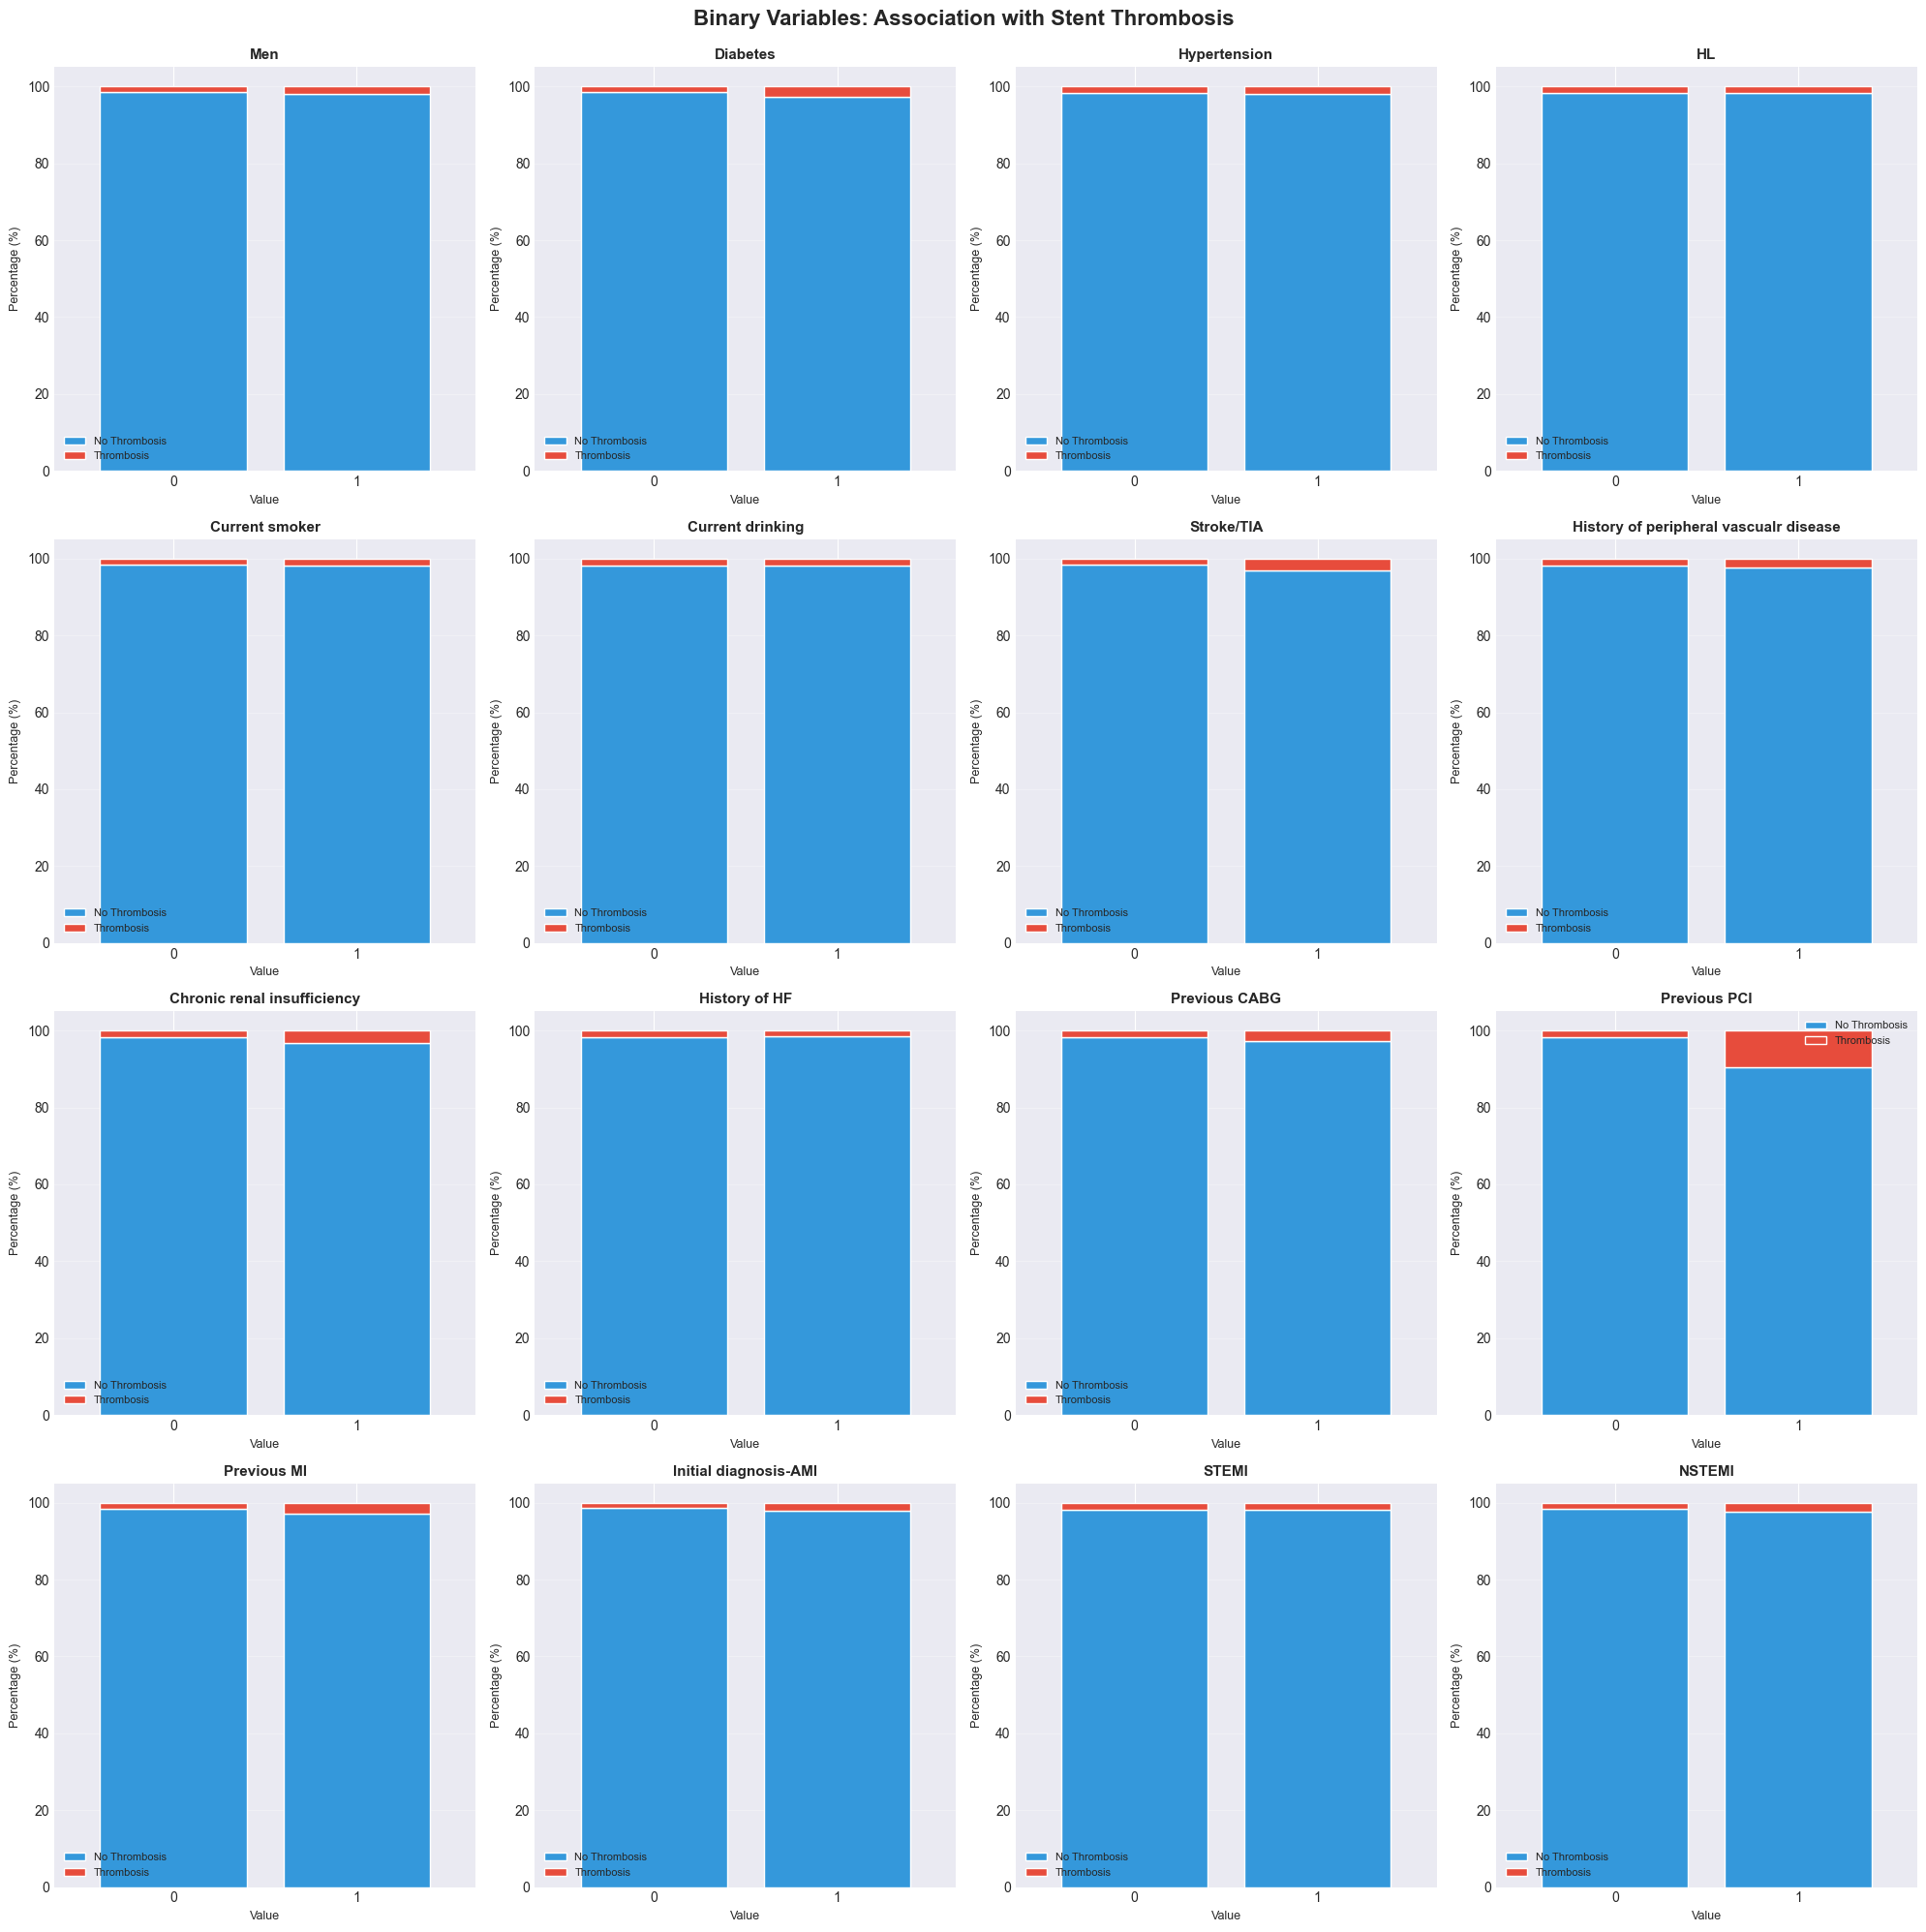

✓ Visualization saved: plots/06_binary_associations.png


In [48]:
# Binary variables association with target
if len(binary_cols) > 0:
    top_binary = binary_cols[:16]  # Top 16 binary variables
    
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    axes = axes.flatten()
    
    for idx, col in enumerate(top_binary):
        try:
            crosstab = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
            crosstab.plot(kind='bar', ax=axes[idx], stacked=True, 
                         color=['#3498db', '#e74c3c'], width=0.8)
            axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Value', fontsize=9)
            axes[idx].set_ylabel('Percentage (%)', fontsize=9)
            axes[idx].set_xticklabels(['0', '1'], rotation=0)
            axes[idx].legend(['No Thrombosis', 'Thrombosis'], fontsize=8)
            axes[idx].grid(True, alpha=0.3, axis='y')
        except:
            axes[idx].axis('off')
    
    plt.suptitle('Binary Variables: Association with Stent Thrombosis', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/06_binary_associations.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Visualization saved: plots/06_binary_associations.png")


## 13. Feature Importance Summary

Combining correlation analysis and statistical significance, we can identify the most important features for predicting stent thrombosis. This comprehensive view helps prioritize features for modeling.


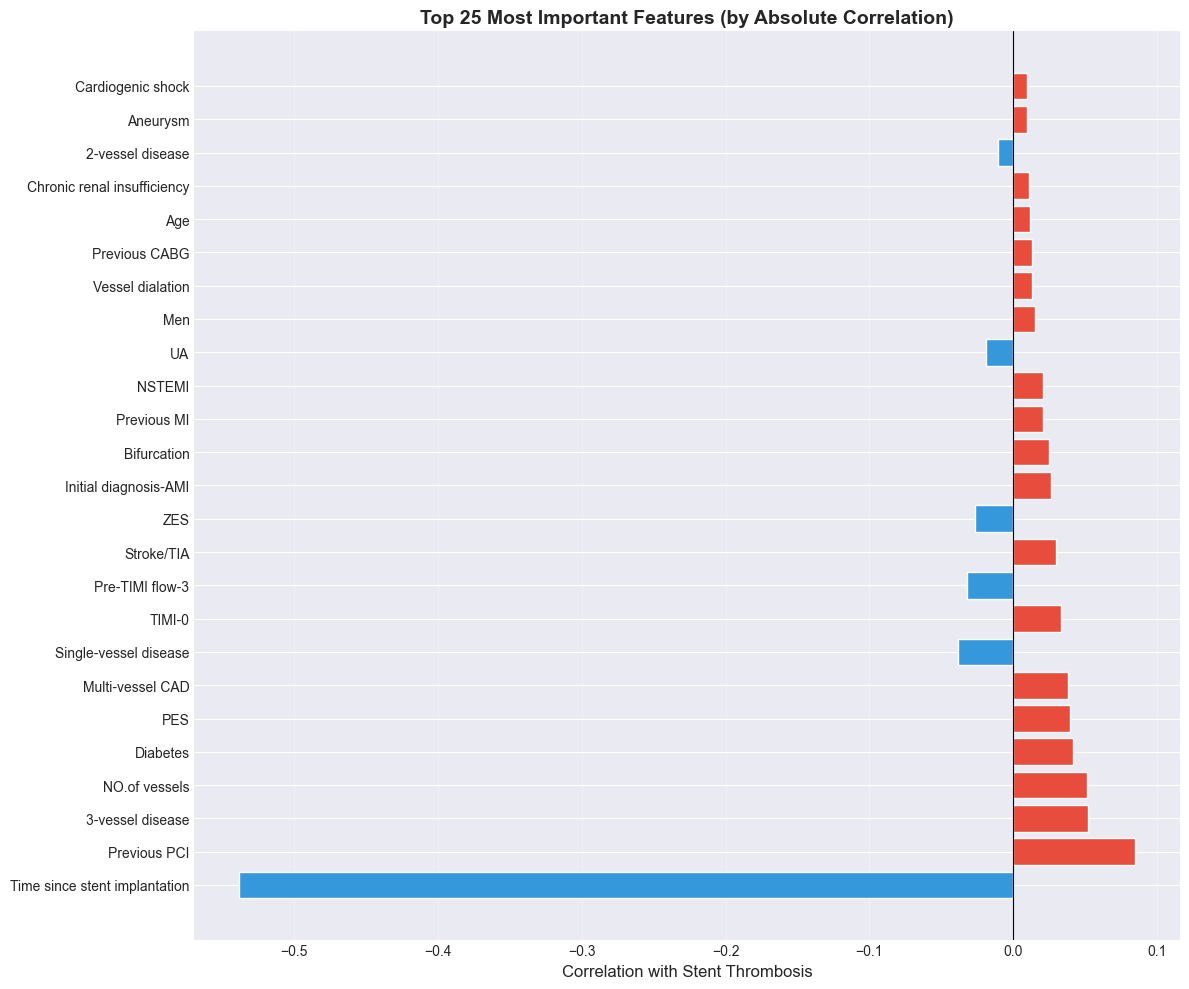

✓ Visualization saved: plots/09_feature_importance.png


In [49]:
# Feature importance summary (combined view)
if TARGET_COL in df.columns and len(correlations) > 0:
    # Create combined importance score
    importance_data = []
    for col in numeric_cols[:50]:  # Top 50 features
        try:
            corr_val = correlations.get(col, 0)
            importance_data.append({
                'Feature': col,
                'Abs_Correlation': abs(corr_val),
                'Correlation': corr_val
            })
        except:
            pass
    
    if importance_data:
        importance_df = pd.DataFrame(importance_data).sort_values('Abs_Correlation', ascending=False).head(25)
        
        fig, ax = plt.subplots(figsize=(12, 10))
        colors = ['#e74c3c' if x > 0 else '#3498db' for x in importance_df['Correlation']]
        ax.barh(range(len(importance_df)), importance_df['Correlation'], color=colors)
        ax.set_yticks(range(len(importance_df)))
        ax.set_yticklabels(importance_df['Feature'])
        ax.set_xlabel('Correlation with Stent Thrombosis', fontsize=12)
        ax.set_title('Top 25 Most Important Features (by Absolute Correlation)', 
                     fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.savefig('../data/result/eda/plots/09_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Visualization saved: plots/09_feature_importance.png")


## 14. Key Insights and Summary

Let's synthesize all the findings from our analysis to extract actionable insights. This summary will help guide:
- **Feature Selection**: Which features are most predictive?
- **Data Preprocessing**: What transformations or imputations are needed?
- **Modeling Strategy**: What techniques should be considered?
- **Clinical Interpretation**: What are the key risk factors?


In [50]:
# Generate key insights
print("=" * 80)
print("KEY INSIGHTS AND SUMMARY")
print("=" * 80)

insights = []

# Target distribution insights
if imbalance_ratio < 0.3:
    insights.append(f"⚠ Class imbalance detected (ratio: {imbalance_ratio:.3f}). Consider using techniques like SMOTE or class weights.")
else:
    insights.append(f"✓ Class distribution is relatively balanced (ratio: {imbalance_ratio:.3f})")

# Missing data insights
if len(missing_df) > 0:
    insights.append(f"⚠ {len(missing_df)} columns have missing values. Total missing: {missing_data.sum():,} ({missing_data.sum()/(df.shape[0]*df.shape[1])*100:.2f}%)")
    insights.append(f"   Consider imputation strategies for columns with <20% missing values.")

# Correlation insights
if TARGET_COL in df.columns and len(correlations) > 0:
    strong_pos = correlations[correlations > 0.3]
    strong_neg = correlations[correlations < -0.3]
    if len(strong_pos) > 0:
        insights.append(f"✓ {len(strong_pos)} features show strong positive correlation (>0.3) with stent thrombosis")
    if len(strong_neg) > 0:
        insights.append(f"✓ {len(strong_neg)} features show strong negative correlation (<-0.3) with stent thrombosis")
    if len(strong_pos) == 0 and len(strong_neg) == 0:
        insights.append("⚠ No features show strong correlation (>0.3) with target. May need feature engineering.")

# Statistical significance insights
if test_results:
    sig_continuous = len([r for r in test_results if r['P-value'] < 0.05])
    if sig_continuous > 0:
        insights.append(f"✓ {sig_continuous} continuous features show statistically significant association (p < 0.05)")

if chi2_results:
    sig_binary = len([r for r in chi2_results if r['P-value'] < 0.05])
    if sig_binary > 0:
        insights.append(f"✓ {sig_binary} binary features show statistically significant association (p < 0.05)")

# Feature count insights
insights.append(f"✓ Dataset contains {len(binary_cols)} binary features, {len(continuous_cols)} continuous features, and {len(categorical_cols)} categorical features")

print("\nKey Insights:")
for i, insight in enumerate(insights, 1):
    print(f"  {i}. {insight}")


KEY INSIGHTS AND SUMMARY

Key Insights:
  1. ⚠ Class imbalance detected (ratio: 0.018). Consider using techniques like SMOTE or class weights.
  2. ✓ 1 features show strong negative correlation (<-0.3) with stent thrombosis
  3. ✓ 12 continuous features show statistically significant association (p < 0.05)
  4. ✓ 10 binary features show statistically significant association (p < 0.05)
  5. ✓ Dataset contains 57 binary features, 24 continuous features, and 1 categorical features


In [51]:
# Top important features
if TARGET_COL in df.columns and len(correlations) > 0:
    print("\n" + "-" * 80)
    print("TOP 10 MOST IMPORTANT FEATURES (by absolute correlation)")
    print("-" * 80)
    top_features = correlations.abs().nlargest(10)
    for idx, (feature, corr) in enumerate(top_features.items(), 1):
        direction = "increases" if correlations[feature] > 0 else "decreases"
        print(f"  {idx:2d}. {feature:40s} | Correlation: {correlations[feature]:7.4f} | {direction} risk")



--------------------------------------------------------------------------------
TOP 10 MOST IMPORTANT FEATURES (by absolute correlation)
--------------------------------------------------------------------------------
   1. Time since stent implantation            | Correlation: -0.5384 | decreases risk
   2. WBC                                      | Correlation:  0.1502 | increases risk
   3. LV                                       | Correlation:  0.1472 | increases risk
   4. eGFR                                     | Correlation: -0.0937 | decreases risk
   5. 1.1:1Post dilation                       | Correlation: -0.0893 | decreases risk
   6. No postdilation                          | Correlation:  0.0893 | increases risk
   7. Previous PCI                             | Correlation:  0.0850 | increases risk
   8. CKD90                                    | Correlation:  0.0626 | increases risk
   9. No.of stents per lesion                  | Correlation:  0.0604 | increases ri

## 15. Export Summary Statistics

Finally, let's save all the summary statistics and analysis results to CSV files for further reference and reporting.


In [52]:
# Save correlations
print("\n" + "=" * 80)
print("SAVING SUMMARY STATISTICS")
print("=" * 80)

if TARGET_COL in df.columns:
    corr_df = pd.DataFrame({
        'Feature': correlations.index,
        'Correlation': correlations.values,
        'Abs_Correlation': correlations.abs().values
    }).sort_values('Abs_Correlation', ascending=False)
    corr_df.to_csv('../data/result/eda/plots/correlations_with_target.csv', index=False)
    print("✓ Saved: plots/correlations_with_target.csv")

# Save statistical test results
if test_results:
    test_df = pd.DataFrame(test_results).sort_values('P-value')
    test_df.to_csv('../data/result/eda/plots/statistical_tests_continuous.csv', index=False)
    print("✓ Saved: plots/statistical_tests_continuous.csv")

if chi2_results:
    chi2_df = pd.DataFrame(chi2_results).sort_values('P-value')
    chi2_df.to_csv('../data/result/eda/plots/statistical_tests_binary.csv', index=False)
    print("✓ Saved: plots/statistical_tests_binary.csv")

# Save data summary
summary = {
    'Total_Rows': df.shape[0],
    'Total_Columns': df.shape[1],
    'Target_Class_0': target_counts.get(0, 0),
    'Target_Class_1': target_counts.get(1, 0),
    'Class_Imbalance_Ratio': imbalance_ratio,
    'Missing_Values_Total': missing_data.sum(),
    'Binary_Features': len(binary_cols),
    'Continuous_Features': len(continuous_cols),
    'Categorical_Features': len(categorical_cols)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('../data/result/eda/plots/data_summary.csv', index=False)
print("✓ Saved: plots/data_summary.csv")



SAVING SUMMARY STATISTICS
✓ Saved: plots/correlations_with_target.csv
✓ Saved: plots/statistical_tests_continuous.csv
✓ Saved: plots/statistical_tests_binary.csv
✓ Saved: plots/data_summary.csv


## 16. Additional Deep-Dive Analyses

Let's perform some additional analyses that provide deeper insights into the data:
- **Demographic Analysis**: Age and gender breakdowns by target
- **Categorical Variable Analysis**: Detailed analysis of stent types and other categorical features
- **Time-based Analysis**: Time since stent implantation patterns
- **Multicollinearity Check**: Identify highly correlated features that might cause redundancy
- **Distribution Shape Analysis**: Skewness and kurtosis for continuous variables


### 16.1 Demographic Analysis

Understanding how demographic factors (age, gender) relate to stent thrombosis can provide important clinical insights.


DEMOGRAPHIC ANALYSIS

Age Statistics by Target:
                   mean  median    std  min  max
Stent thrombosis                                
0                 59.83    60.0   9.93   28   89
1                 60.71    62.0  11.33   29   83


Gender Distribution by Target:
Stent thrombosis     0   1   All
Men                             
0                 1604  24  1628
1                 3489  68  3557
All               5093  92  5185

Gender Distribution (Percentages):
Stent thrombosis      0     1
Men                          
0                 98.53  1.47
1                 98.09  1.91


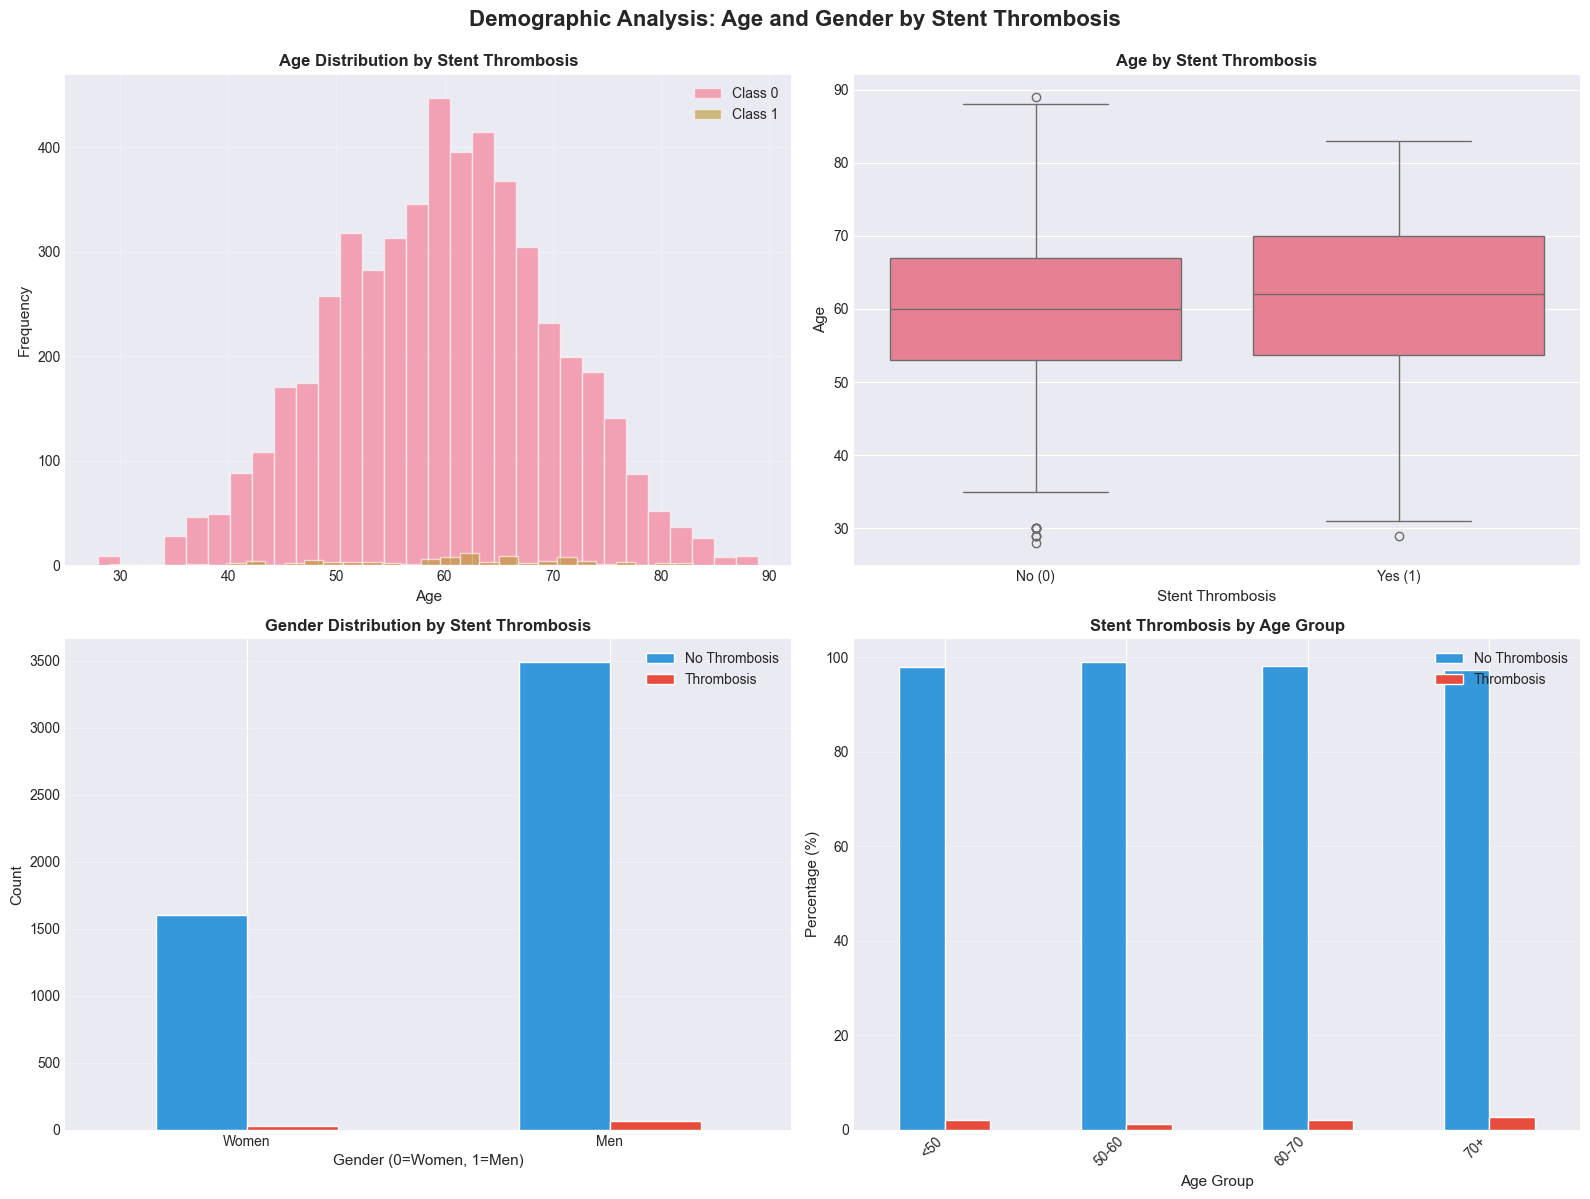


✓ Visualization saved: plots/10_demographic_analysis.png


In [53]:
# Demographic analysis
if 'Age' in df.columns and 'Men' in df.columns:
    print("=" * 80)
    print("DEMOGRAPHIC ANALYSIS")
    print("=" * 80)
    
    # Age analysis
    print("\nAge Statistics by Target:")
    age_by_target = df.groupby(TARGET_COL)['Age'].agg(['mean', 'median', 'std', 'min', 'max'])
    print(age_by_target.round(2))
    
    # Gender analysis
    print("\n\nGender Distribution by Target:")
    gender_crosstab = pd.crosstab(df['Men'], df[TARGET_COL], margins=True)
    print(gender_crosstab)
    print("\nGender Distribution (Percentages):")
    gender_pct = pd.crosstab(df['Men'], df[TARGET_COL], normalize='index') * 100
    print(gender_pct.round(2))
    
    # Visualize demographics
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Age distribution by target
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]['Age'].dropna()
        axes[0, 0].hist(data, alpha=0.6, label=f'Class {target_val}', bins=30)
    axes[0, 0].set_title('Age Distribution by Stent Thrombosis', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Age', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Age box plot
    sns.boxplot(data=df, x=TARGET_COL, y='Age', ax=axes[0, 1])
    axes[0, 1].set_title('Age by Stent Thrombosis', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Stent Thrombosis', fontsize=11)
    axes[0, 1].set_ylabel('Age', fontsize=11)
    axes[0, 1].set_xticklabels(['No (0)', 'Yes (1)'])
    
    # Gender distribution
    gender_target = pd.crosstab(df['Men'], df[TARGET_COL])
    gender_target.plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e74c3c'])
    axes[1, 0].set_title('Gender Distribution by Stent Thrombosis', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Gender (0=Women, 1=Men)', fontsize=11)
    axes[1, 0].set_ylabel('Count', fontsize=11)
    axes[1, 0].legend(['No Thrombosis', 'Thrombosis'])
    axes[1, 0].set_xticklabels(['Women', 'Men'], rotation=0)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Age groups analysis
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 50, 60, 70, 100], labels=['<50', '50-60', '60-70', '70+'])
    age_group_crosstab = pd.crosstab(df['Age_Group'], df[TARGET_COL], normalize='index') * 100
    age_group_crosstab.plot(kind='bar', ax=axes[1, 1], color=['#3498db', '#e74c3c'])
    axes[1, 1].set_title('Stent Thrombosis by Age Group', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Age Group', fontsize=11)
    axes[1, 1].set_ylabel('Percentage (%)', fontsize=11)
    axes[1, 1].legend(['No Thrombosis', 'Thrombosis'])
    axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Demographic Analysis: Age and Gender by Stent Thrombosis', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/10_demographic_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Visualization saved: plots/10_demographic_analysis.png")
    
    # Clean up temporary column
    df.drop('Age_Group', axis=1, inplace=True)


### 16.2 Categorical Variable Analysis

Let's analyze categorical variables like stent types to understand their distribution and relationship with the target.


In [54]:
# Categorical variable analysis
if len(categorical_cols) > 0:
    print("=" * 80)
    print("CATEGORICAL VARIABLE ANALYSIS")
    print("=" * 80)
    
    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Most common values:")
        value_counts = df[col].value_counts().head(10)
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"    {val}: {count} ({pct:.2f}%)")
        
        # Analyze relationship with target
        if df[col].nunique() <= 20:  # Only for variables with reasonable number of categories
            print(f"\n  Relationship with Stent Thrombosis:")
            crosstab = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
            print(crosstab.round(2))
            
            # Statistical test if binary
            if df[col].nunique() == 2:
                try:
                    contingency = pd.crosstab(df[col], df[TARGET_COL])
                    if contingency.shape == (2, 2) and contingency.min().min() > 0:
                        chi2, p_value, dof, expected = chi2_contingency(contingency)
                        print(f"  Chi-square test: p-value = {p_value:.4f}")
                except:
                    pass
        print("-" * 80)


CATEGORICAL VARIABLE ANALYSIS

Stent type-SES:
  Unique values: 106
  Most common values:
    Partner: 1017 (19.61%)
    Excel: 959 (18.50%)
    Resolute: 844 (16.28%)
    Firebird: 750 (14.46%)
    Tivoli: 590 (11.38%)
    XX: 249 (4.80%)
    XV: 198 (3.82%)
    XienceV: 184 (3.55%)
    excel: 30 (0.58%)
    XP: 25 (0.48%)
--------------------------------------------------------------------------------


### 17.3 Time-Based Analysis

"Time since stent implantation" is a critical feature. Let's analyze how time patterns relate to stent thrombosis.


TIME-BASED ANALYSIS

Time since stent implantation statistics:
  Mean: 1410.0 days (3.86 years)
  Median: 1416.0 days (3.88 years)
  Min: 380.0 days (1.04 years)
  Max: 1605.0 days (4.39 years)

Time statistics by Target:
                     mean  median     std   min   max
Stent thrombosis                                     
0                 1420.11  1419.0  107.70  1241  1605
1                  848.05   736.0  383.77   380  1575


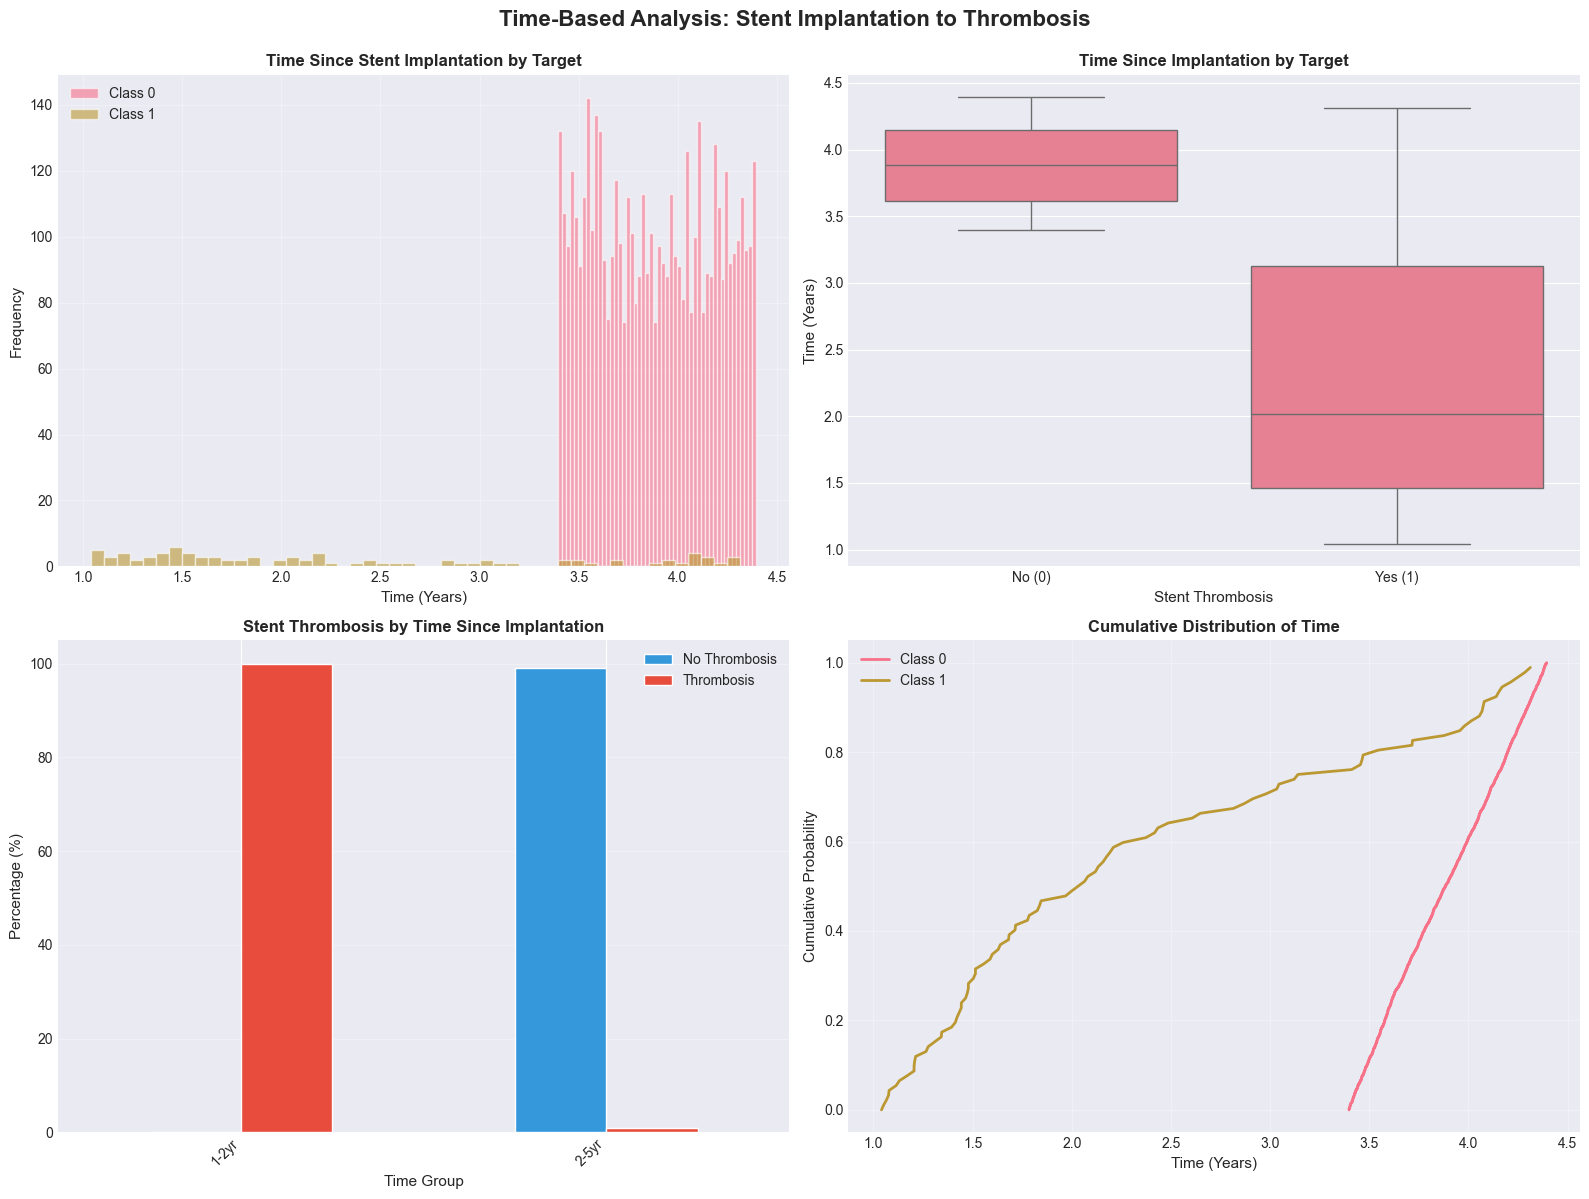


✓ Visualization saved: plots/11_time_analysis.png


In [55]:
# Time-based analysis
time_col = 'Time since stent implantation'
if time_col in df.columns:
    print("=" * 80)
    print("TIME-BASED ANALYSIS")
    print("=" * 80)
    
    # Convert to years for easier interpretation
    df['Time_years'] = df[time_col] / 365.25
    
    print(f"\nTime since stent implantation statistics:")
    print(f"  Mean: {df[time_col].mean():.1f} days ({df['Time_years'].mean():.2f} years)")
    print(f"  Median: {df[time_col].median():.1f} days ({df['Time_years'].median():.2f} years)")
    print(f"  Min: {df[time_col].min():.1f} days ({df['Time_years'].min():.2f} years)")
    print(f"  Max: {df[time_col].max():.1f} days ({df['Time_years'].max():.2f} years)")
    
    print(f"\nTime statistics by Target:")
    time_by_target = df.groupby(TARGET_COL)[time_col].agg(['mean', 'median', 'std', 'min', 'max'])
    print(time_by_target.round(2))
    
    # Create time groups
    df['Time_Group'] = pd.cut(df['Time_years'], 
                              bins=[0, 1, 2, 5, 10, 100], 
                              labels=['<1yr', '1-2yr', '2-5yr', '5-10yr', '10+yr'])
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Distribution by target
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]['Time_years'].dropna()
        axes[0, 0].hist(data, alpha=0.6, label=f'Class {target_val}', bins=50)
    axes[0, 0].set_title('Time Since Stent Implantation by Target', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Time (Years)', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Box plot
    sns.boxplot(data=df, x=TARGET_COL, y='Time_years', ax=axes[0, 1])
    axes[0, 1].set_title('Time Since Implantation by Target', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Stent Thrombosis', fontsize=11)
    axes[0, 1].set_ylabel('Time (Years)', fontsize=11)
    axes[0, 1].set_xticklabels(['No (0)', 'Yes (1)'])
    
    # Time groups
    time_group_crosstab = pd.crosstab(df['Time_Group'], df[TARGET_COL], normalize='index') * 100
    time_group_crosstab.plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e74c3c'])
    axes[1, 0].set_title('Stent Thrombosis by Time Since Implantation', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Time Group', fontsize=11)
    axes[1, 0].set_ylabel('Percentage (%)', fontsize=11)
    axes[1, 0].legend(['No Thrombosis', 'Thrombosis'])
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Cumulative distribution
    for target_val in [0, 1]:
        data = df[df[TARGET_COL] == target_val]['Time_years'].dropna().sort_values()
        axes[1, 1].plot(data, np.arange(len(data))/len(data), 
                       label=f'Class {target_val}', linewidth=2)
    axes[1, 1].set_title('Cumulative Distribution of Time', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Time (Years)', fontsize=11)
    axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Time-Based Analysis: Stent Implantation to Thrombosis', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('../data/result/eda/plots/11_time_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Visualization saved: plots/11_time_analysis.png")
    
    # Clean up temporary columns
    df.drop(['Time_years', 'Time_Group'], axis=1, inplace=True)


### 16.4 Multicollinearity Analysis

High correlations between features can indicate redundancy and may cause issues in modeling. Let's identify highly correlated feature pairs.


MULTICOLLINEARITY ANALYSIS

⚠ Found 4 highly correlated feature pairs (|r| > 0.7):

Top 20 highly correlated pairs:


,Feature 1,Feature 2,Correlation
0,Min-stent diameter,Max-stent diameter,0.904075
2,TCL,LDL,0.878888
1,Total stent length,No.of stents per lesion,0.863269
3,Fast-Glu,HbA1c,0.761349


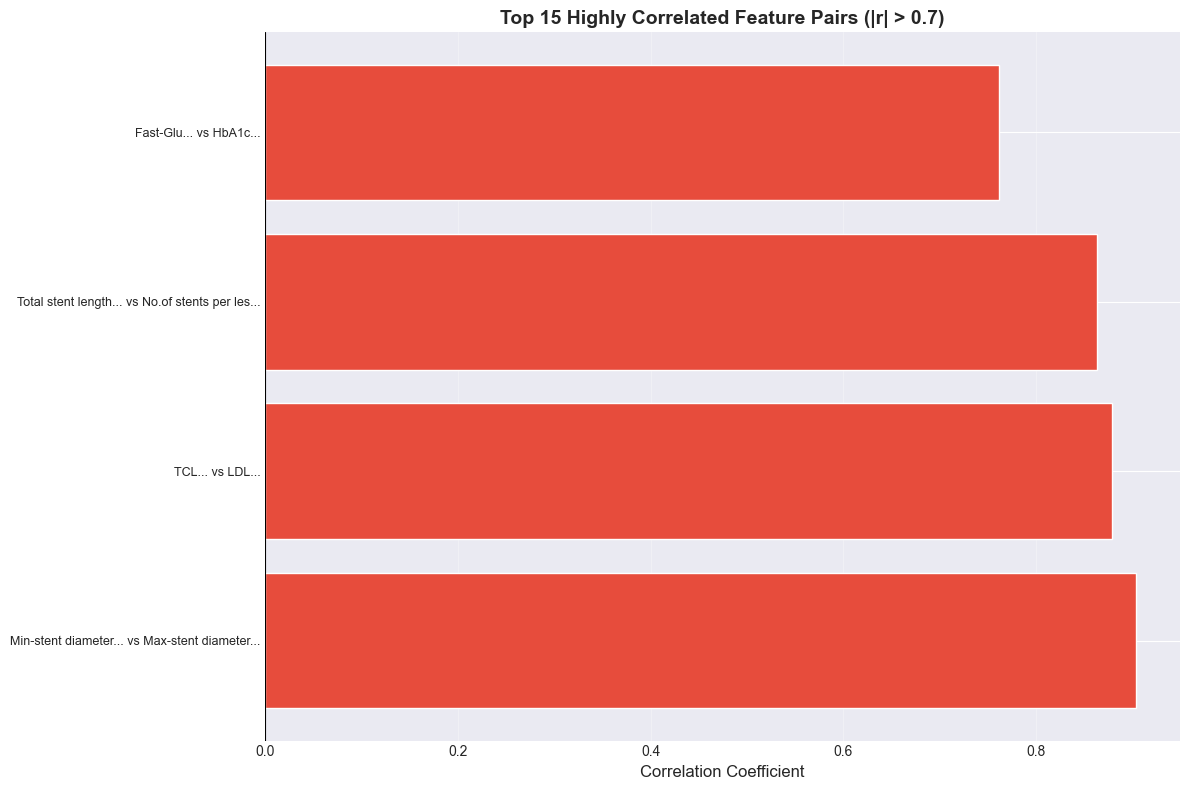


✓ Visualization saved: plots/12_multicollinearity.png


In [56]:
# Multicollinearity analysis
if len(continuous_cols) > 0:
    print("=" * 80)
    print("MULTICOLLINEARITY ANALYSIS")
    print("=" * 80)
    
    # Calculate correlation matrix for continuous variables
    corr_matrix = df[continuous_cols].corr()
    
    # Find highly correlated pairs (excluding diagonal and duplicates)
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:  # Threshold for high correlation
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_val
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
        print(f"\n⚠ Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > 0.7):")
        print("\nTop 20 highly correlated pairs:")
        display(high_corr_df.head(20))
        
        # Visualize top correlations
        if len(high_corr_pairs) > 0:
            top_pairs = high_corr_df.head(15)
            fig, ax = plt.subplots(figsize=(12, 8))
            y_pos = np.arange(len(top_pairs))
            colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_pairs['Correlation']]
            ax.barh(y_pos, top_pairs['Correlation'], color=colors)
            ax.set_yticks(y_pos)
            ax.set_yticklabels([f"{row['Feature 1'][:20]}... vs {row['Feature 2'][:20]}..." 
                               for _, row in top_pairs.iterrows()], fontsize=9)
            ax.set_xlabel('Correlation Coefficient', fontsize=12)
            ax.set_title('Top 15 Highly Correlated Feature Pairs (|r| > 0.7)', 
                         fontsize=14, fontweight='bold')
            ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
            ax.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.savefig('../data/result/eda/plots/12_multicollinearity.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("\n✓ Visualization saved: plots/12_multicollinearity.png")
    else:
        print("\n✓ No highly correlated feature pairs found (|r| > 0.7)")
        print("  This suggests low multicollinearity, which is good for modeling.")


### 16.5 Distribution Shape Analysis

Understanding the shape of distributions (skewness and kurtosis) helps determine if transformations are needed for modeling.


DISTRIBUTION SHAPE ANALYSIS

Distribution Shape Statistics (Top 20 by absolute skewness):


,Feature,Skewness,Kurtosis,Abs_Skewness,Interpretation_Skew,Interpretation_Kurt
14,Cre,7.484056,161.335262,7.484056,Highly Skewed,Heavy Tailed
10,CaI,2.834164,9.432386,2.834164,Highly Skewed,Heavy Tailed
16,CKD5,2.617650,7.507913,2.617650,Highly Skewed,Heavy Tailed
21,Fast-Glu,2.417145,7.838604,2.417145,Highly Skewed,Heavy Tailed
1,Time since stent implantation,-2.359276,13.211717,2.359276,Highly Skewed,Heavy Tailed
20,TG,2.134846,8.837294,2.134846,Highly Skewed,Heavy Tailed
7,No.of stents per lesion,2.131825,4.700423,2.131825,Highly Skewed,Heavy Tailed
5,Total stent length,1.737190,4.154201,1.737190,Highly Skewed,Heavy Tailed
23,Fiberinogen,1.621689,5.653460,1.621689,Highly Skewed,Heavy Tailed
9,LVEF,-1.482588,7.416341,1.482588,Highly Skewed,Heavy Tailed



⚠ 14 features are highly skewed (|skewness| > 1)
   Consider log transformation or other normalization techniques.


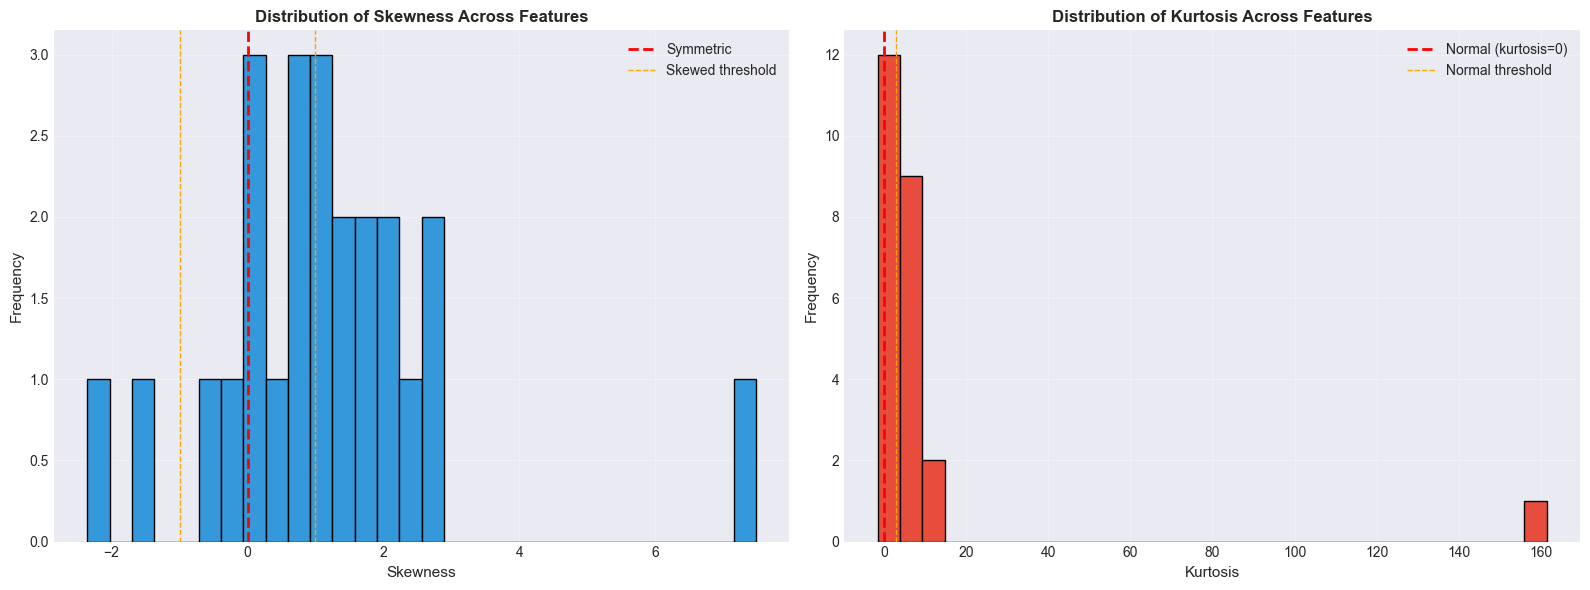


✓ Visualization saved: plots/13_distribution_shape.png


In [57]:
# Distribution shape analysis
if len(continuous_cols) > 0:
    print("=" * 80)
    print("DISTRIBUTION SHAPE ANALYSIS")
    print("=" * 80)
    
    from scipy.stats import skew, kurtosis
    
    shape_stats = []
    for col in continuous_cols:
        data = df[col].dropna()
        if len(data) > 3:
            skewness = skew(data)
            kurt = kurtosis(data)
            shape_stats.append({
                'Feature': col,
                'Skewness': skewness,
                'Kurtosis': kurt,
                'Abs_Skewness': abs(skewness),
                'Interpretation_Skew': 'Highly Skewed' if abs(skewness) > 1 else 'Moderately Skewed' if abs(skewness) > 0.5 else 'Symmetric',
                'Interpretation_Kurt': 'Heavy Tailed' if kurt > 3 else 'Light Tailed' if kurt < 0 else 'Normal'
            })
    
    if shape_stats:
        shape_df = pd.DataFrame(shape_stats).sort_values('Abs_Skewness', ascending=False)
        print("\nDistribution Shape Statistics (Top 20 by absolute skewness):")
        display(shape_df.head(20))
        
        # Summary
        highly_skewed = shape_df[shape_df['Abs_Skewness'] > 1]
        if len(highly_skewed) > 0:
            print(f"\n⚠ {len(highly_skewed)} features are highly skewed (|skewness| > 1)")
            print("   Consider log transformation or other normalization techniques.")
        
        # Visualize skewness distribution
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        axes[0].hist(shape_df['Skewness'], bins=30, color='#3498db', edgecolor='black')
        axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Symmetric')
        axes[0].axvline(x=1, color='orange', linestyle='--', linewidth=1, label='Skewed threshold')
        axes[0].axvline(x=-1, color='orange', linestyle='--', linewidth=1)
        axes[0].set_title('Distribution of Skewness Across Features', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Skewness', fontsize=11)
        axes[0].set_ylabel('Frequency', fontsize=11)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].hist(shape_df['Kurtosis'], bins=30, color='#e74c3c', edgecolor='black')
        axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Normal (kurtosis=0)')
        axes[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Normal threshold')
        axes[1].set_title('Distribution of Kurtosis Across Features', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Kurtosis', fontsize=11)
        axes[1].set_ylabel('Frequency', fontsize=11)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('../data/result/eda/plots/13_distribution_shape.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("\n✓ Visualization saved: plots/13_distribution_shape.png")


## 17. Final Summary and Recommendations

Based on all analyses performed, here are the final recommendations for data preprocessing and modeling.


In [58]:
print("=" * 80)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

recommendations = []

# Data quality recommendations
if 'missing_df' in locals() and len(missing_df) > 0:
    high_missing = missing_df[missing_df['Missing Percentage'] > 20]
    if len(high_missing) > 0:
        recommendations.append(f"⚠ Consider removing or imputing {len(high_missing)} features with >20% missing values")
    recommendations.append("✓ Use appropriate imputation strategies (mean/median for continuous, mode for categorical)")

# Feature engineering recommendations
if 'correlations' in locals() and len(correlations) > 0:
    weak_corr = correlations[abs(correlations) < 0.1]
    if len(weak_corr) > 0:
        recommendations.append(f"⚠ {len(weak_corr)} features show very weak correlation (<0.1) - consider feature engineering or removal")

# Transformation recommendations
if 'shape_df' in locals():
    highly_skewed = shape_df[shape_df['Abs_Skewness'] > 1] if 'shape_df' in locals() else []
    if len(highly_skewed) > 0:
        recommendations.append(f"⚠ {len(highly_skewed)} features are highly skewed - consider log/square root transformation")

# Modeling recommendations
if 'imbalance_ratio' in locals() and imbalance_ratio < 0.3:
    recommendations.append("⚠ Use stratified sampling and consider SMOTE, class weights, or ensemble methods")
    recommendations.append("✓ Use appropriate metrics: AUC-ROC, Precision-Recall, F1-score (not just accuracy)")

if 'high_corr_pairs' in locals() and len(high_corr_pairs) > 0:
    recommendations.append(f"⚠ {len(high_corr_pairs)} highly correlated feature pairs detected - consider feature selection or PCA")

recommendations.append("✓ Use cross-validation with stratification to maintain class distribution")
recommendations.append("✓ Consider feature selection techniques (mutual information, recursive feature elimination)")

print("\nRecommendations for Data Preprocessing and Modeling:")
for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. {rec}")

print("\n" + "=" * 80)
print("EDA COMPLETE - All analyses finished!")
print("=" * 80)
print(f"\nTotal visualizations generated: 13")
print(f"Total summary files: 4")
print("\nAll outputs saved to '../data/result/eda/plots/' directory")


FINAL SUMMARY AND RECOMMENDATIONS

Recommendations for Data Preprocessing and Modeling:
  1. ⚠ 78 features show very weak correlation (<0.1) - consider feature engineering or removal
  2. ⚠ 14 features are highly skewed - consider log/square root transformation
  3. ⚠ Use stratified sampling and consider SMOTE, class weights, or ensemble methods
  4. ✓ Use appropriate metrics: AUC-ROC, Precision-Recall, F1-score (not just accuracy)
  5. ⚠ 4 highly correlated feature pairs detected - consider feature selection or PCA
  6. ✓ Use cross-validation with stratification to maintain class distribution
  7. ✓ Consider feature selection techniques (mutual information, recursive feature elimination)

EDA COMPLETE - All analyses finished!

Total visualizations generated: 13
Total summary files: 4

All outputs saved to '../data/result/eda/plots/' directory
